# Modèle de Deep Learning : ResNet_50

Les modèles de Deep Learning sont entraînés directement à partir des images issues du pipeline de prétraitement à trois classes.

Afin de garantir une comparaison équitable avec les autres modèles de Deep Learning du projet, les mêmes jeux de données sont utilisés :

- `COVID-19_Radiography_Dataset_split_3classes/train_augmented` pour l'entraînement ;
- `COVID-19_Radiography_Dataset_split_3classes/validation` pour la validation ;
- `COVID-19_Radiography_Dataset_split_3classes/test` pour l'évaluation finale.

Les classes utilisées sont :

- `COVID` ;
- `Normal` ;
- `Pneumonia`.

La classe `Pneumonia` résulte de la fusion des classes initiales `Lung_Opacity` et `Viral Pneumonia`.

Aucune nouvelle augmentation d'images n'est appliquée pendant l'entraînement, le jeu `train_augmented` contenant déjà les images augmentées communes à l'ensemble des modèles de Deep Learning.

La distribution des classes est vérifiée dans le dossier `train_augmented`.

Le jeu de validation et le jeu de test conservent leur distribution naturelle afin de fournir une évaluation représentative des performances du modèle.

La différence relative entre chaque classe et la classe la plus représentée est calculée afin de quantifier le déséquilibre du jeu d'entraînement.

Cette version du modèle applique une pondération des classes (`class_weight`) lors de l'entraînement. Les poids sont calculés automatiquement à partir de la distribution des données d'entraînement afin de limiter l'influence de la classe majoritaire et d'améliorer les performances sur les classes minoritaires.

# Préparation

## Environnement de travail

In [3]:
# Imports et configuration générale

from pathlib import Path
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score
)

# Graine utilisée pour améliorer la reproductibilité
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Imports réalisés avec succès.")
print("Seed :", SEED)

I0000 00:00:1785736456.395167    2209 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785736456.679708    2209 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785736458.460733    2209 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Imports réalisés avec succès.
Seed : 42


In [2]:
# Vérification gpu

print("=" * 70)
print("Python :", sys.executable)
print("TensorFlow :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError(
        "Aucun GPU détecté. Vérifie que le kernel sélectionné est "
        "'Python (Covid19_gpu)'."
    )

print("GPU détecté(s) :", gpus)

for gpu in gpus:
    details = tf.config.experimental.get_device_details(gpu)
    print(
        "Nom du GPU :",
        details.get("device_name", gpu.name)
    )

print("=" * 70)

Python : /home/noura/miniforge3/envs/Covid19_gpu/bin/python
TensorFlow : 2.21.0
GPU détecté(s) : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Nom du GPU : NVIDIA GeForce RTX 4090 Laptop GPU


In [3]:
# Allocation progressive de la mémoire GPU

gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as error:
        print(
            "La mémoire GPU a déjà été initialisée :",
            error
        )

print("Allocation progressive de la mémoire GPU configurée.")

Allocation progressive de la mémoire GPU configurée.


## Définition des chemins vers les jeux d’images

Les modèles de deep learning utilisent directement les images.

Pour garantir une comparaison équitable avec les autres modèles de l’équipe,
les jeux suivants sont utilisés :

- `train_augmented` pour l’entraînement ;
- `validation` pour la validation ;
- `test` pour l’évaluation finale.

Les chemins sont écrits au format WSL, le disque Windows `C:` étant accessible
depuis Ubuntu sous `/mnt/c/`.

In [4]:
# Dossier principal contenant les jeux d'images (analyse 3 classes)
DATASET_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID/"
    "COVID-19_Radiography_Dataset_split_3classes"
)

# Dossiers utilisés pour ResNet50
TRAIN_DIR = DATASET_DIR / "train_augmented"
VAL_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

dataset_paths = {
    "Entraînement": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}

print("Dossier principal :", DATASET_DIR)
print()

for dataset_name, dataset_path in dataset_paths.items():
    print(f"{dataset_name} :")
    print(f"  Chemin : {dataset_path}")
    print(f"  Existe : {dataset_path.exists()}")
    print()

Dossier principal : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split_3classes

Entraînement :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split_3classes/train_augmented
  Existe : True

Validation :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split_3classes/validation
  Existe : True

Test :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split_3classes/test
  Existe : True



In [5]:
missing_directories = [
    str(dataset_path)
    for dataset_path in dataset_paths.values()
    if not dataset_path.exists()
]

if missing_directories:
    raise FileNotFoundError(
        "Les dossiers suivants sont introuvables :\n"
        + "\n".join(missing_directories)
    )

print("Les trois dossiers ont été trouvés avec succès.")

Les trois dossiers ont été trouvés avec succès.


# Vérification des données

## Détection et cohérence des classes

Les noms des classes sont détectés automatiquement à partir des sous-dossiers.

Cette étape vérifie que :

- les trois jeux contiennent les mêmes classes ;
- aucune classe n’est absente ;
- l’ordre des classes est identique pour l’entraînement, la validation et le test.

In [6]:
def get_class_names(directory: Path) -> list[str]:
    """
    Retourne les noms des sous-dossiers correspondant aux classes.
    """
    return sorted(
        folder.name
        for folder in directory.iterdir()
        if folder.is_dir()
    )


train_class_names = get_class_names(TRAIN_DIR)
val_class_names = get_class_names(VAL_DIR)
test_class_names = get_class_names(TEST_DIR)

print("Classes du train :")
print(train_class_names)

print("\nClasses de validation :")
print(val_class_names)

print("\nClasses du test :")
print(test_class_names)

Classes du train :
['COVID', 'Normal', 'Pneumonia']

Classes de validation :
['COVID', 'Normal', 'Pneumonia']

Classes du test :
['COVID', 'Normal', 'Pneumonia']


In [7]:
if not train_class_names:
    raise ValueError(
        "Aucune classe n'a été détectée dans le dossier d'entraînement."
    )

if train_class_names != val_class_names:
    raise ValueError(
        "Les classes du train et de la validation ne sont pas identiques.\n"
        f"Train : {train_class_names}\n"
        f"Validation : {val_class_names}"
    )

if train_class_names != test_class_names:
    raise ValueError(
        "Les classes du train et du test ne sont pas identiques.\n"
        f"Train : {train_class_names}\n"
        f"Test : {test_class_names}"
    )

class_names = train_class_names
NUM_CLASSES = len(class_names)

print("Cohérence des classes validée.")
print("Nombre de classes :", NUM_CLASSES)
print("Ordre des labels :", class_names)


Cohérence des classes validée.
Nombre de classes : 3
Ordre des labels : ['COVID', 'Normal', 'Pneumonia']


## Distribution des images par classe

Cette étape compte le nombre d’images présentes dans chaque classe pour :

- l’entraînement augmenté ;
- la validation ;
- le test.

L’objectif est de vérifier la répartition des données et de détecter une éventuelle anomalie avant la création des jeux TensorFlow.

In [8]:
IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


def count_images_by_class(
    directory: Path,
    class_names: list[str]
) -> dict[str, int]:
    """
    Compte les fichiers image présents dans chaque sous-dossier de classe.
    """
    counts = {}

    for class_name in class_names:
        class_directory = directory / class_name

        image_count = sum(
            1
            for file_path in class_directory.rglob("*")
            if (
                file_path.is_file()
                and file_path.suffix.lower() in IMAGE_EXTENSIONS
            )
        )

        counts[class_name] = image_count

    return counts


train_counts = count_images_by_class(
    TRAIN_DIR,
    class_names
)

val_counts = count_images_by_class(
    VAL_DIR,
    class_names
)

test_counts = count_images_by_class(
    TEST_DIR,
    class_names
)

distribution_df = pd.DataFrame({
    "Classe": class_names,
    "Entraînement": [
        train_counts[class_name]
        for class_name in class_names
    ],
    "Validation": [
        val_counts[class_name]
        for class_name in class_names
    ],
    "Test": [
        test_counts[class_name]
        for class_name in class_names
    ]
})

distribution_df

,Classe,Entraînement,Validation,Test
0,COVID,5396,338,337
1,Normal,16218,1013,1014
2,Pneumonia,11722,732,733


In [9]:
totals = distribution_df[
    ["Entraînement", "Validation", "Test"]
].sum()

print("Nombre total d'images par jeu :")
print()

for dataset_name, total in totals.items():
    print(f"{dataset_name} : {total:,} images")

Nombre total d'images par jeu :

Entraînement : 33,336 images
Validation : 2,083 images
Test : 2,084 images


In [10]:
empty_classes = []

for _, row in distribution_df.iterrows():
    class_name = row["Classe"]

    for dataset_name in [
        "Entraînement",
        "Validation",
        "Test"
    ]:
        if row[dataset_name] == 0:
            empty_classes.append(
                f"{dataset_name} — {class_name}"
            )

if empty_classes:
    raise ValueError(
        "Certaines classes ne contiennent aucune image :\n"
        + "\n".join(empty_classes)
    )

print("Toutes les classes contiennent au moins une image.")

Toutes les classes contiennent au moins une image.


## Analyse de la répartition des classes

Cette section complète le comptage précédent en calculant la proportion de chaque classe dans les jeux d’entraînement, de validation et de test.

Elle permet de vérifier :

- le niveau de déséquilibre entre les classes ;
- la cohérence des répartitions entre les trois jeux ;
- l’absence d’anomalie dans les splits.

In [11]:
proportion_df = distribution_df.copy()

for dataset_name in [
    "Entraînement",
    "Validation",
    "Test"
]:
    total_images = proportion_df[dataset_name].sum()

    proportion_df[f"{dataset_name} (%)"] = (
        proportion_df[dataset_name]
        / total_images
        * 100
    ).round(2)

proportion_df[
    [
        "Classe",
        "Entraînement (%)",
        "Validation (%)",
        "Test (%)"
    ]
]


,Classe,Entraînement (%),Validation (%),Test (%)
0,COVID,16.19,16.23,16.17
1,Normal,48.65,48.63,48.66
2,Pneumonia,35.16,35.14,35.17


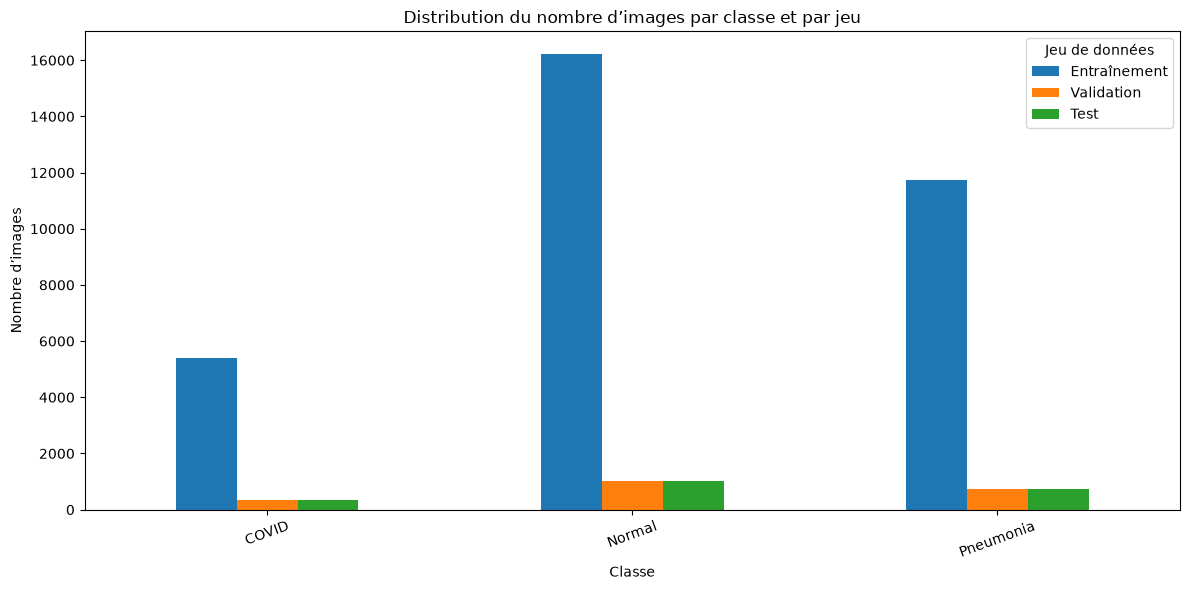

In [12]:
distribution_plot_df = distribution_df.set_index("Classe")

ax = distribution_plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Distribution du nombre d’images par classe et par jeu"
)
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre d’images")
ax.tick_params(
    axis="x",
    rotation=20
)
ax.legend(
    title="Jeu de données"
)

plt.tight_layout()
plt.show()

Le découpage stratifié conserve les proportions des trois classes dans les jeux d’entraînement, de validation et de test. Le jeu reste .toutefois déséquilibré, avec une prédominance de la classe Normal

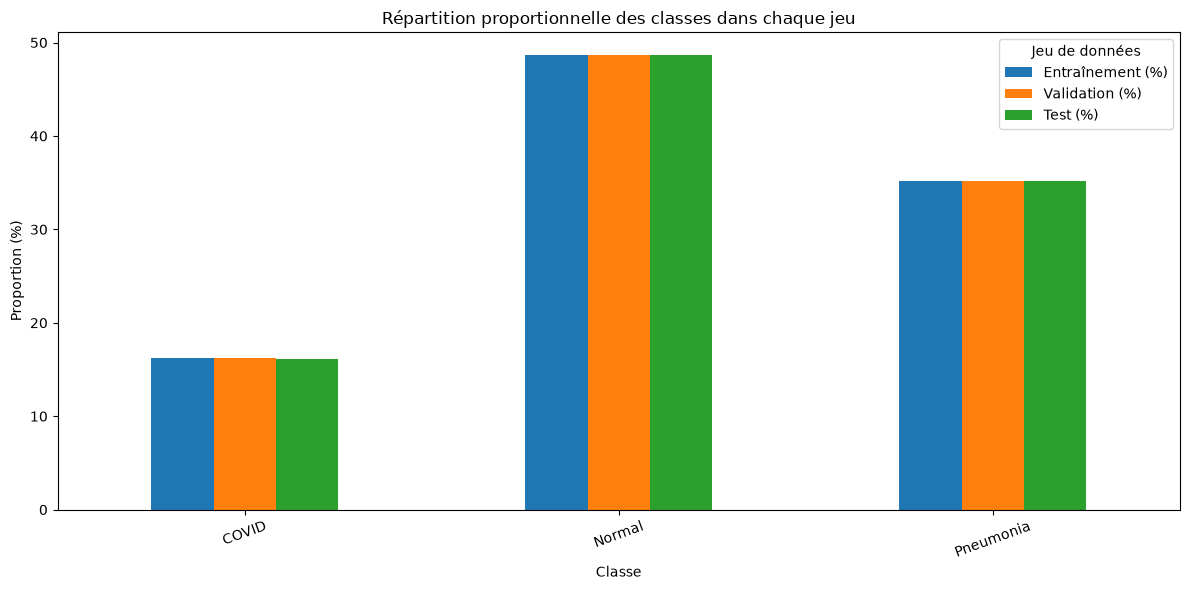

In [13]:
percentage_plot_df = proportion_df.set_index("Classe")[
    [
        "Entraînement (%)",
        "Validation (%)",
        "Test (%)"
    ]
]

ax = percentage_plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Répartition proportionnelle des classes dans chaque jeu"
)
ax.set_xlabel("Classe")
ax.set_ylabel("Proportion (%)")
ax.tick_params(
    axis="x",
    rotation=20
)
ax.legend(
    title="Jeu de données"
)

plt.tight_layout()
plt.show()

Les proportions des trois classes sont identiques dans les jeux d'entraînement, de validation et de test, confirmant un découpage stratifié.

## Vérification visuelle des images

Avant de créer les jeux de données TensorFlow, quelques images sont affichées afin de vérifier :

- le bon chargement des fichiers ;
- l'absence d'images corrompues ;
- le format RGB des images ;
- les dimensions des images ;
- la correspondance entre les images et leurs labels.

In [14]:
# Sélection aléatoire des images

from PIL import Image

# Nombre d'images affichées par classe
N_IMAGES = 4

random.seed(SEED)

selected_images = {}

for class_name in class_names:

    class_folder = TRAIN_DIR / class_name

    image_files = [
        file
        for file in class_folder.iterdir()
        if file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    selected_images[class_name] = random.sample(
        image_files,
        k=min(N_IMAGES, len(image_files))
    )

print("Images sélectionnées avec succès.")

Images sélectionnées avec succès.


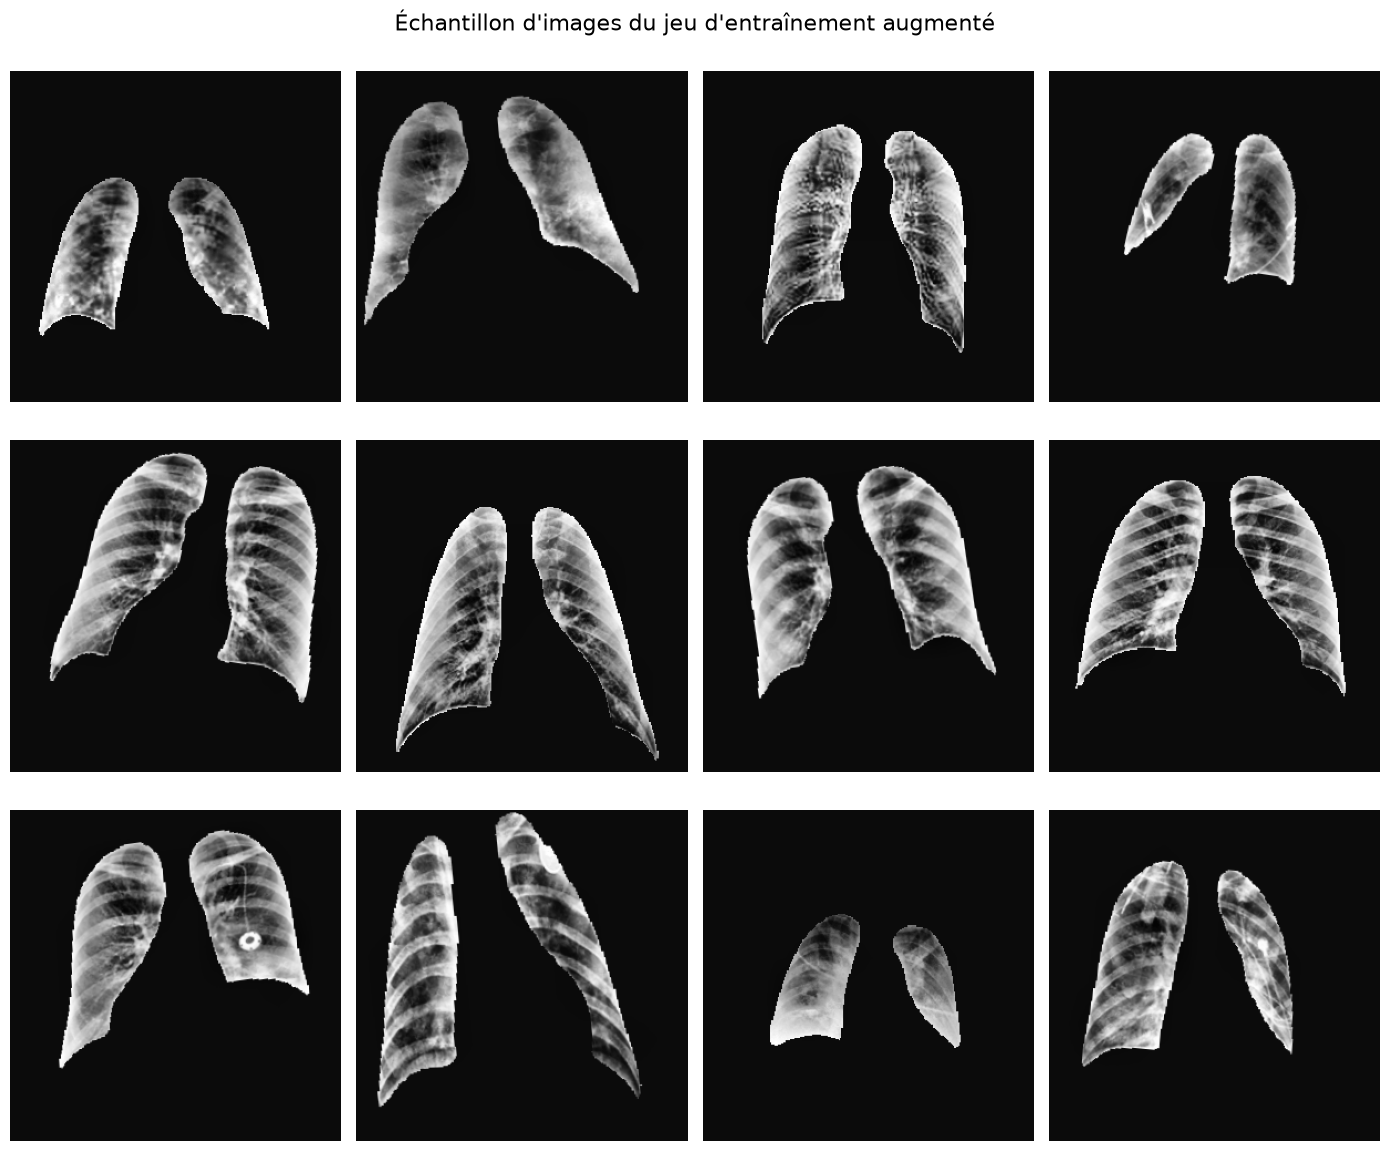

In [15]:
# Affichage

fig, axes = plt.subplots(
    len(class_names),
    N_IMAGES,
    figsize=(14, 12)
)

for row, class_name in enumerate(class_names):

    for col, image_path in enumerate(selected_images[class_name]):

        image = Image.open(image_path).convert("RGB")

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(
                class_name,
                fontsize=12,
                rotation=90,
                labelpad=15
            )

plt.suptitle(
    "Échantillon d'images du jeu d'entraînement augmenté",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [16]:
# Vérification des propriétés

print("=" * 70)

for class_name in class_names:

    image_path = selected_images[class_name][0]

    image = Image.open(image_path)

    print(f"\nClasse : {class_name}")
    print(f"Nom du fichier : {image_path.name}")
    print(f"Dimensions : {image.size}")
    print(f"Mode : {image.mode}")


Classe : COVID
Nom du fichier : COVID-904.png
Dimensions : (299, 299)
Mode : L

Classe : Normal
Nom du fichier : Normal-3085_aug1.png
Dimensions : (299, 299)
Mode : L

Classe : Pneumonia
Nom du fichier : Lung_Opacity-1936_aug1.png
Dimensions : (299, 299)
Mode : L


# Préparation des données

## Paramètres de chargement des images

Les images seront redimensionnées au format attendu par ResNet.

Les paramètres suivants sont communs aux jeux d’entraînement, de validation et de test afin de garantir une comparaison cohérente.

In [17]:
# Dimensions d'entrée du modèle
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# Taille des lots
BATCH_SIZE = 32

# Nombre de classes détectées précédemment
NUM_CLASSES = len(class_names)

print("Dimensions des images :", IMG_SIZE)
print("Taille des batchs :", BATCH_SIZE)
print("Nombre de classes :", NUM_CLASSES)

Dimensions des images : (224, 224)
Taille des batchs : 32
Nombre de classes : 3


## Création des jeux de données TensorFlow

Le jeu d’entraînement est chargé depuis le dossier `train_augmented`.

Les labels sont encodés sous forme d’entiers, ce qui permettra d’utiliser la fonction de perte `sparse_categorical_crossentropy`.

Les jeux de validation et de test sont créés avec les mêmes paramètres que le jeu d'entraînement.

Contrairement au jeu d'entraînement, les images ne sont pas mélangées (`shuffle=False`) afin de garantir un ordre stable des échantillons lors de l'évaluation finale et du calcul de la matrice de confusion.

In [18]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("\nJeu d'entraînement créé avec succès.")
print("Classes :", train_ds.class_names)

Found 33336 files belonging to 3 classes.


I0000 00:00:1785597418.254934   72863 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13512 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



Jeu d'entraînement créé avec succès.
Classes : ['COVID', 'Normal', 'Pneumonia']


In [19]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nJeux de données créés avec succès.")
print(f"Train      : {len(train_ds)} batches")
print(f"Validation : {len(val_ds)} batches")
print(f"Test       : {len(test_ds)} batches")

Found 2083 files belonging to 3 classes.
Found 2084 files belonging to 3 classes.

Jeux de données créés avec succès.
Train      : 1042 batches
Validation : 66 batches
Test       : 66 batches


## Vérification d’un batch TensorFlow

Cette étape permet de contrôler la forme des tenseurs, le type des données,
la plage des valeurs de pixels et la correspondance entre les images et leurs labels.

In [20]:
# Récupération d'un batch du jeu d'entraînement
images_batch, labels_batch = next(iter(train_ds))

print("Forme du batch d'images :", images_batch.shape)
print("Forme du batch de labels :", labels_batch.shape)

print("\nType des images :", images_batch.dtype)
print("Type des labels :", labels_batch.dtype)

print("\nValeur minimale des pixels :", tf.reduce_min(images_batch).numpy())
print("Valeur maximale des pixels :", tf.reduce_max(images_batch).numpy())

print("\nPremiers labels numériques :")
print(labels_batch[:10].numpy())

Forme du batch d'images : (32, 224, 224, 3)
Forme du batch de labels : (32,)

Type des images : <dtype: 'float32'>
Type des labels : <dtype: 'int32'>

Valeur minimale des pixels : 0.6897974
Valeur maximale des pixels : 255.0

Premiers labels numériques :
[0 1 2 1 1 1 1 1 0 2]


In [21]:
print("Correspondance des labels :")
print()

for class_index, class_name in enumerate(class_names):
    print(f"{class_index} -> {class_name}")

Correspondance des labels :

0 -> COVID
1 -> Normal
2 -> Pneumonia


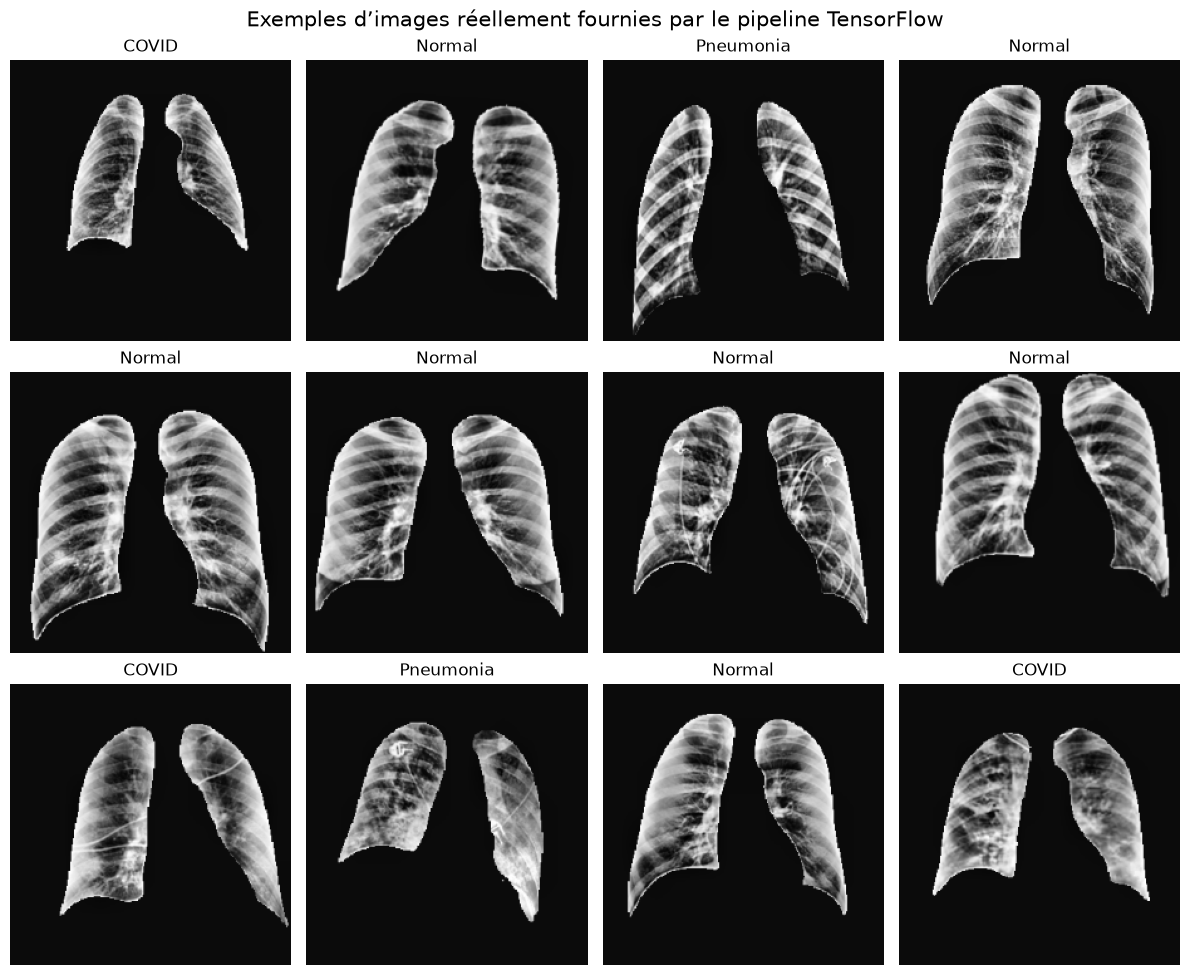

In [22]:
plt.figure(figsize=(12, 10))

for index in range(min(12, len(images_batch))):
    ax = plt.subplot(3, 4, index + 1)

    image = images_batch[index].numpy().astype("uint8")
    label_index = int(labels_batch[index].numpy())
    label_name = class_names[label_index]

    plt.imshow(image)
    plt.title(label_name)
    plt.axis("off")

plt.suptitle(
    "Exemples d’images réellement fournies par le pipeline TensorFlow",
    fontsize=15
)

plt.tight_layout()
plt.show()

## Optimisation du pipeline TensorFlow

Avant l'entraînement, les jeux de données sont optimisés afin d'améliorer les performances :

- application du prétraitement officiel de ResNet50 ;
- mise en cache des données (`cache()`) ;
- préchargement asynchrone (`prefetch()`).

Ces optimisations réduisent le temps d'entraînement sans modifier les données.

In [23]:
# Import du prétraitement

from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

In [24]:
#Fonction de prétraitement

def preprocess(image, label):
    """
    Prétraitement officiel de ResNet50.

    Les images passent d'un intervalle [0 ; 255]
    au format attendu par ResNet50.
    """
    image = preprocess_input(image)

    return image, label

In [25]:
#Pipeline optimisé

train_ds = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

print("Pipeline TensorFlow optimisé avec succès.")

Pipeline TensorFlow optimisé avec succès.


## Prise en compte du déséquilibre des classes

Le jeu d’entraînement contient davantage d’images dans certaines classes,
notamment dans la classe `Normal`.

Des poids de classes sont donc calculés selon la formule dite *balanced*.
Une erreur sur une classe minoritaire aura ainsi un poids plus important
pendant l’entraînement.

In [26]:
from sklearn.utils.class_weight import compute_class_weight

# Nombre d'images de chaque classe dans le jeu d'entraînement
train_class_counts = np.array([
    train_counts[class_name]
    for class_name in class_names
])

# Reconstruction des labels du jeu d'entraînement à partir des effectifs
train_labels_for_weights = np.concatenate([
    np.full(
        fill_value=class_index,
        shape=train_class_counts[class_index],
        dtype=np.int32
    )
    for class_index in range(NUM_CLASSES)
])

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels_for_weights
)

class_weights = {
    class_index: float(weight)
    for class_index, weight in enumerate(class_weights_array)
}

print("Poids de classes calculés :")
print()

for class_index, class_name in enumerate(class_names):
    print(
        f"{class_index} — {class_name:<20} "
        f": {class_weights[class_index]:.4f}"
    )

Poids de classes calculés :

0 — COVID                : 2.0593
1 — Normal               : 0.6852
2 — Pneumonia            : 0.9480


In [27]:
# Vérification de la formule

class_weights_df = pd.DataFrame({
    "Indice": range(NUM_CLASSES),
    "Classe": class_names,
    "Nombre d'images": train_class_counts,
    "Poids": [
        class_weights[index]
        for index in range(NUM_CLASSES)
    ]
})

class_weights_df

,Indice,Classe,Nombre d'images,Poids
0,0,COVID,5396,2.059303
1,1,Normal,16218,0.685165
2,2,Pneumonia,11722,0.947961


# Modélisation

## Construction du modèle ResNet50

Un modèle ResNet50 pré-entraîné sur ImageNet est utilisé comme extracteur de caractéristiques.

Dans un premier temps, les couches convolutives sont gelées. Seule une nouvelle tête de classification adaptée aux quatre classes du projet sera entraînée.

In [28]:
# Téléchargement

from tensorflow.keras.applications import ResNet50

# Chargement de ResNet50 sans sa couche de classification d'origine
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Gel de toutes les couches pré-entraînées
base_model.trainable = False

print("ResNet50 chargé avec succès.")
print("Nombre total de couches :", len(base_model.layers))
print("Modèle de base entraînable :", base_model.trainable)

ResNet50 chargé avec succès.
Nombre total de couches : 175
Modèle de base entraînable : False


In [29]:
# Construction de la tête de classification

inputs = keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="input_image"
)

# Passage dans ResNet50
x = base_model(
    inputs,
    training=False
)

# Réduction de chaque carte de caractéristiques à une valeur moyenne
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

# Régularisation afin de limiter le surapprentissage
x = layers.Dropout(
    0.4,
    name="dropout"
)(x)

# Classification finale sur les trois classes
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_COVID19"
)

print("Modèle complet construit avec succès.")

Modèle complet construit avec succès.


In [30]:
# Vérification du modèle

model.summary()

Model: "ResNet50_COVID19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.trainable_weights
)

non_trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
)

print(f"Paramètres entraînables     : {trainable_params:,}")
print(f"Paramètres non entraînables : {non_trainable_params:,}")

Paramètres entraînables     : 6,147
Paramètres non entraînables : 23,587,712


## Code de rechargement des modèles si besoin

Code_1

Dossier principal du projet au format WSL
PROJECT_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID"
)

Dossier contenant les modèles sauvegardés
OUTPUT_DIR = PROJECT_DIR / "outputs_resnet50"

Meilleur modèle obtenu après la phase 1
PHASE1_MODEL_PATH = (
    OUTPUT_DIR / "resnet50_phase1_best.keras"
)

Vérification de l'existence du fichier
if not PHASE1_MODEL_PATH.exists():
    raise FileNotFoundError(
        "Le modèle de phase 1 est introuvable :\n"
        f"{PHASE1_MODEL_PATH}"
    )

Chargement du modèle complet
model = keras.models.load_model(
    PHASE1_MODEL_PATH
)

print("✅ Modèle de phase 1 chargé avec succès.")
print("Nom du modèle :", model.name)
print("Chemin :", PHASE1_MODEL_PATH)

Code_2

Récupération du modèle ResNet50 imbriqué
base_model = model.get_layer("resnet50")

print("Modèle de base :", base_model.name)
print("Nombre de couches :", len(base_model.layers))
print("Entraînable :", base_model.trainable)


## Phase 1 : Transfer Learning

### Compilation du modèle — Phase 1

Dans cette première phase, le réseau ResNet50 reste entièrement gelé.

Seule la nouvelle couche de classification est entraînée avec :

- l’optimiseur Adam ;
- un taux d’apprentissage de `1e-4` ;
- la fonction de perte `SparseCategoricalCrossentropy`, adaptée aux labels entiers ;
- l’accuracy comme métrique de suivi.

Des callbacks permettent de sauvegarder le meilleur modèle, de réduire le taux
d’apprentissage en cas de stagnation et d’arrêter l’entraînement avant le
surapprentissage.

In [5]:
# Dossier principal du projet au format WSL
PROJECT_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID"
)

# Dossier contenant les résultats du ResNet50 (analyse 3 classes)
OUTPUT_DIR = PROJECT_DIR / "outputs_resnet50_3classes"

# Création uniquement si le dossier n'existe pas encore
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Modèles sauvegardés
PHASE1_MODEL_PATH = (
    OUTPUT_DIR / "resnet50_3classes_phase1_best.keras"
)

PHASE2_MODEL_PATH = (
    OUTPUT_DIR / "resnet50_3classes_finetuning_best.keras"
)

print("Dossier du projet :", PROJECT_DIR)
print("Dossier de sortie :", OUTPUT_DIR)
print("Modèle phase 1    :", PHASE1_MODEL_PATH)
print("Modèle fine-tuné  :", PHASE2_MODEL_PATH)

Dossier du projet : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID
Dossier de sortie : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes
Modèle phase 1    : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_3classes_phase1_best.keras
Modèle fine-tuné  : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_3classes_finetuning_best.keras


In [33]:
print("\nVérification des fichiers existants :")
print(
    "Modèle phase 1 trouvé :",
    PHASE1_MODEL_PATH.exists()
)
print(
    "Modèle fine-tuné trouvé :",
    PHASE2_MODEL_PATH.exists()
)


Vérification des fichiers existants :
Modèle phase 1 trouvé : False
Modèle fine-tuné trouvé : False


In [34]:
# Compilation

LEARNING_RATE_PHASE1 = 1e-4

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_PHASE1
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Modèle compilé avec succès.")
print("Learning rate phase 1 :", LEARNING_RATE_PHASE1)

Modèle compilé avec succès.
Learning rate phase 1 : 0.0001


In [35]:
# Définition du callback pour le suivi du F1_macro

class MacroF1Callback(tf.keras.callbacks.Callback):
    """
    Calcule le F1 macro sur les jeux d'entraînement et de validation
    à la fin de chaque époque.
    """

    def __init__(self, train_ds, val_ds):

        super().__init__()

        self.train_ds = train_ds
        self.val_ds = val_ds

    def _compute_f1(self, dataset):

        y_true = []
        y_pred = []

        for images, labels in dataset:

            predictions = self.model.predict(
                images,
                verbose=0
            )

            predictions = np.argmax(
                predictions,
                axis=1
            )

            y_true.extend(labels.numpy())
            y_pred.extend(predictions)

        return f1_score(
            y_true,
            y_pred,
            average="macro"
        )

    def on_epoch_end(self, epoch, logs=None):

        logs = logs or {}

        train_f1 = self._compute_f1(self.train_ds)
        val_f1 = self._compute_f1(self.val_ds)

        logs["f1_macro"] = train_f1
        logs["val_f1_macro"] = val_f1

        print(
            f"\nMacro F1 : "
            f"{train_f1:.4f} "
            f"- "
            f"val_macro_f1 : "
            f"{val_f1:.4f}"
        )

In [36]:
macro_f1_callback = MacroF1Callback(
    train_ds=train_ds,
    val_ds=val_ds
)

In [37]:
# Définition des callbacks

callbacks_phase1 = [

    macro_f1_callback,

    keras.callbacks.ModelCheckpoint(
        filepath=PHASE1_MODEL_PATH,
        monitor="val_f1_macro",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro",
        mode="max",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configurés :", len(callbacks_phase1))

for callback in callbacks_phase1:
    print("-", callback.__class__.__name__)

Callbacks configurés : 4
- MacroF1Callback
- ModelCheckpoint
- EarlyStopping
- ReduceLROnPlateau


### Entraînement de la tête de classification

Dans cette première phase, toutes les couches de ResNet50 restent gelées.

Seule la tête de classification ajoutée au modèle est entraînée pendant un maximum de 20 époques. Les poids de classes sont utilisés afin de limiter l’impact du déséquilibre entre les catégories.

In [38]:
EPOCHS_PHASE1 = 20

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1,
    class_weight=class_weights
)

Epoch 1/20


/home/noura/miniforge3/envs/Covid19_gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1785597710.185769   74134 service.cc:153] XLA service 0x7c4740067420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785597710.185809   74134 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1785597710.378124   74134 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785597711.725219   74134 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1785597711.802182   74134 dot_m

   3/1042 ━━━━━━━━━━━━━━━━━━━━ 1:03 61ms/step - accuracy: 0.3542 - loss: 1.5459 

I0000 00:00:1785597717.665435   74134 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1040/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5945 - loss: 0.9856

I0000 00:00:1785597747.591404   74134 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10889__.181


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5945 - loss: 0.9858
Macro F1 : 0.7035 - val_macro_f1 : 0.7081

Epoch 1: val_f1_macro improved from None to 0.70811, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_3classes_phase1_best.keras

Epoch 1: finished saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_3classes_phase1_best.keras
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 155s 139ms/step - accuracy: 0.5945 - loss: 0.9858 - val_accuracy: 0.7408 - val_loss: 0.6365 - f1_macro: 0.7035 - val_f1_macro: 0.7081 - learning_rate: 1.0000e-04
Epoch 2/20
1041/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6877 - loss: 0.7665
Macro F1 : 0.7197 - val_macro_f1 : 0.7197

Epoch 2: val_f1_macro improved from 0.70811 to 0.71973, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_3class

In [39]:
epochs_completed_phase1 = len(history_phase1.history["loss"])

best_epoch_phase1 = (
    np.argmax(history_phase1.history["val_f1_macro"]) + 1
)

best_val_f1_phase1 = float(
    np.max(history_phase1.history["val_f1_macro"])
)

best_val_loss_phase1 = float(
    history_phase1.history["val_loss"][
        best_epoch_phase1 - 1
    ]
)

best_val_accuracy_phase1 = float(
    history_phase1.history["val_accuracy"][
        best_epoch_phase1 - 1
    ]
)

print("Phase 1 terminée.")
print("Nombre d'époques exécutées :", epochs_completed_phase1)
print("Meilleure époque :", best_epoch_phase1)
print(f"Meilleur val_f1_macro : {best_val_f1_phase1:.4f}")
print(f"Val_loss à la meilleure époque : {best_val_loss_phase1:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase1:.4f}"
)
print("Modèle sauvegardé dans :", PHASE1_MODEL_PATH)

Phase 1 terminée.
Nombre d'époques exécutées : 20
Meilleure époque : 19
Meilleur val_f1_macro : 0.7799
Val_loss à la meilleure époque : 0.4933
Val_accuracy à la meilleure époque : 0.8118
Modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_3classes_phase1_best.keras


### Analyse de l’entraînement de la phase 1

Les courbes de perte et d’accuracy permettent d’évaluer la convergence du modèle
et de détecter un éventuel surapprentissage avant le fine-tuning.

In [40]:
history_phase1_df = pd.DataFrame(
    history_phase1.history
)

history_phase1_df.index = np.arange(
    1,
    len(history_phase1_df) + 1
)

history_phase1_df.index.name = "Époque"

history_phase1_df

,accuracy,loss,val_accuracy,val_loss,f1_macro,val_f1_macro,learning_rate
Époque,,,,,,,
1,0.594492,0.985813,0.740759,0.636496,0.703504,0.708114,0.00010
2,0.687575,0.766695,0.748920,0.606948,0.719658,0.719729,0.00010
3,0.716763,0.702575,0.762362,0.576313,0.731174,0.731956,0.00010
4,0.734131,0.663728,0.779165,0.548266,0.744571,0.747859,0.00010
5,0.747150,0.637677,0.787806,0.534761,0.750841,0.756151,0.00010
6,0.752280,0.621585,0.781085,0.545825,0.749935,0.750929,0.00010
7,0.760439,0.611007,0.793567,0.524384,0.759203,0.762152,0.00010
8,0.763649,0.603013,0.794527,0.523726,0.759320,0.764364,0.00010
9,0.768329,0.596238,0.798368,0.524068,0.762186,0.768049,0.00010


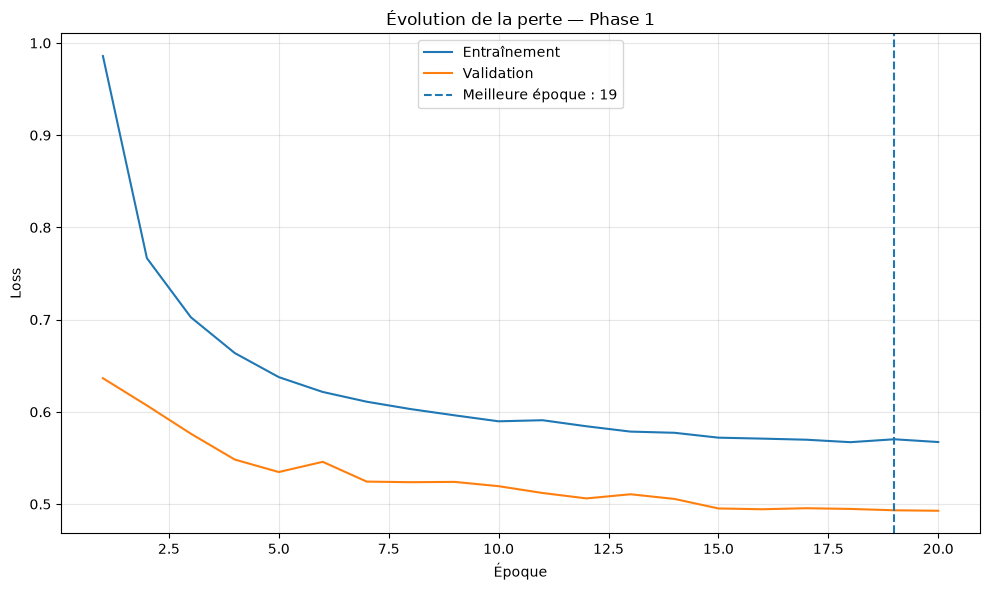

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_phase1_df.index,
    history_phase1_df["loss"],
    label="Entraînement"
)

plt.plot(
    history_phase1_df.index,
    history_phase1_df["val_loss"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase1,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase1}"
)

plt.title("Évolution de la perte — Phase 1")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

La perte diminue régulièrement au cours de l'entraînement, tandis que la perte de validation suit la même tendance et atteint son minimum à l'époque 19. L'absence de divergence marquée entre les deux courbes suggère un apprentissage stable, sans signe notable de surapprentissage durant cette première phase.

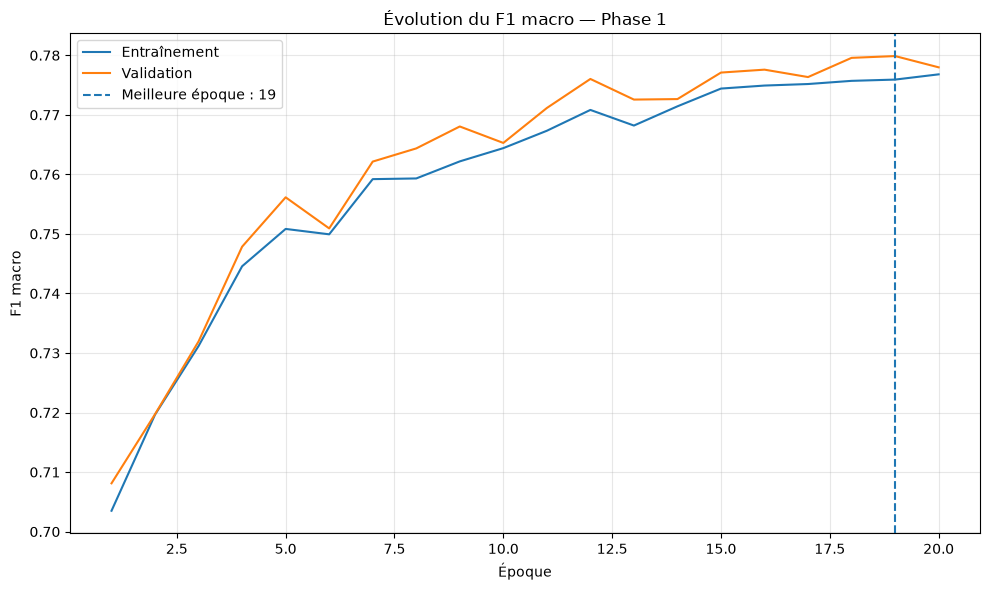

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_phase1_df.index,
    history_phase1_df["f1_macro"],
    label="Entraînement"
)

plt.plot(
    history_phase1_df.index,
    history_phase1_df["val_f1_macro"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase1,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase1}"
)

plt.title("Évolution du F1 macro — Phase 1")
plt.xlabel("Époque")
plt.ylabel("F1 macro")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Le F1 macro augmente régulièrement au cours de l'entraînement et atteint son maximum à l'époque 19. Les courbes d'entraînement et de validation restent très proches, ce qui traduit une bonne capacité de généralisation et un apprentissage stable, sans signe de surapprentissage durant cette première phase.

In [43]:
final_train_loss = history_phase1_df["loss"].iloc[-1]
final_val_loss = history_phase1_df["val_loss"].iloc[-1]

final_train_f1 = history_phase1_df[
    "f1_macro"
].iloc[-1]

final_val_f1 = history_phase1_df[
    "val_f1_macro"
].iloc[-1]

final_train_accuracy = history_phase1_df[
    "accuracy"
].iloc[-1]

final_val_accuracy = history_phase1_df[
    "val_accuracy"
].iloc[-1]

print("Dernière époque exécutée :")
print(f"Train loss     : {final_train_loss:.4f}")
print(f"Validation loss: {final_val_loss:.4f}")
print()

print(f"Train F1 macro     : {final_train_f1:.4f}")
print(f"Validation F1 macro: {final_val_f1:.4f}")
print(
    f"Écart de F1 macro train-validation : "
    f"{final_train_f1 - final_val_f1:.4f}"
)
print()

print(f"Train accuracy     : {final_train_accuracy:.4f}")
print(f"Validation accuracy: {final_val_accuracy:.4f}")

Dernière époque exécutée :
Train loss     : 0.5673
Validation loss: 0.4928

Train F1 macro     : 0.7768
Validation F1 macro: 0.7780
Écart de F1 macro train-validation : -0.0012

Train accuracy     : 0.7818
Validation accuracy: 0.8104


### Évaluation du modèle après phase 1 sur le jeu de test

Avant le fine-tuning, le modèle obtenu à l'issue de la phase 1 est évalué
sur le jeu de test indépendant.

Cette évaluation servira de référence (baseline) pour comparer les
performances obtenues après le fine-tuning.

Les métriques calculées sont :

- Accuracy
- Balanced Accuracy
- Precision (macro)
- Recall (macro)
- F1-score (macro)
- Matrice de confusion
- Rapport de classification

In [44]:
# Chargement du meilleur modèle

best_model_phase1 = keras.models.load_model(
    PHASE1_MODEL_PATH
)

print("Meilleur modèle chargé.")

Meilleur modèle chargé.


In [45]:
# Prédiction

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    probabilities = best_model_phase1.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_prob.extend(probabilities)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Nombre d'images évaluées :", len(y_true))

Nombre d'images évaluées : 2084


In [46]:
# Calcul des métriques

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

results_phase1 = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "Valeur": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1
    ]
})

results_phase1

,Métrique,Valeur
0,Accuracy,0.808541
1,Balanced Accuracy,0.786531
2,Precision macro,0.769924
3,Recall macro,0.786531
4,F1 macro,0.774834


In [47]:
# Rapport de classification
print("Rapport - Phase 1:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


Rapport - Phase 1:
              precision    recall  f1-score   support

       COVID     0.5833    0.7270    0.6473       337
      Normal     0.8736    0.8659    0.8697      1014
   Pneumonia     0.8528    0.7667    0.8075       733

    accuracy                         0.8085      2084
   macro avg     0.7699    0.7865    0.7748      2084
weighted avg     0.8194    0.8085    0.8119      2084



Le modèle obtient un F1 macro de 0,775. Les classes Normal et Pneumonia sont bien reconnues, tandis que COVID reste la plus difficile à classifier. Les performances sont légèrement inférieures à celles du modèle à 4 classes.

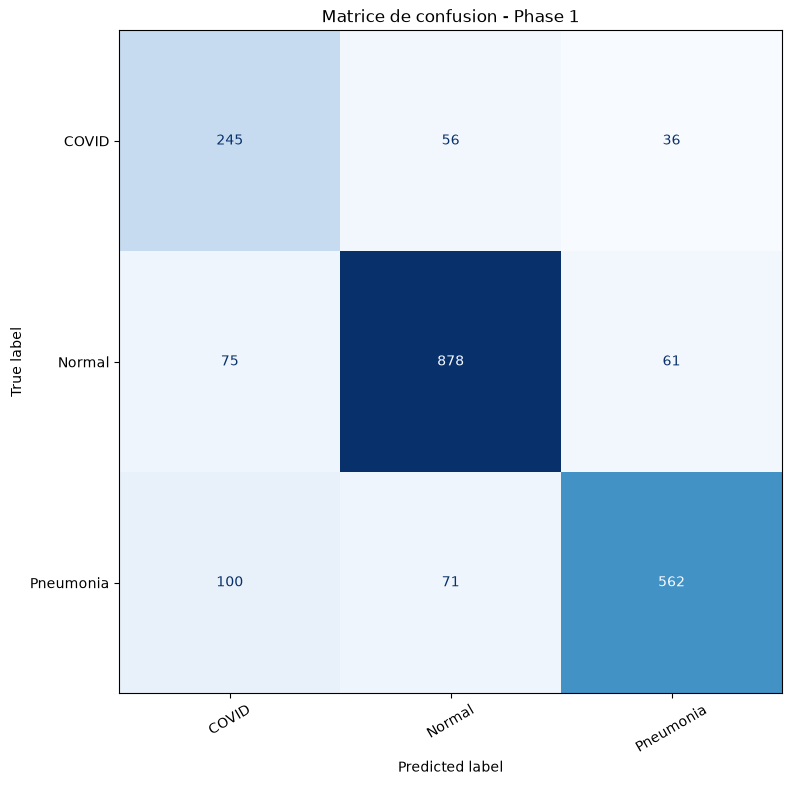

In [48]:
# Matrice de confusion

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Matrice de confusion - Phase 1")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

La matrice de confusion confirme que la classe Normal est la mieux reconnue (878 prédictions correctes). Les principales erreurs concernent les confusions entre COVID et Pneumonia, montrant que ces deux classes restent les plus difficiles à distinguer malgré leur regroupement en trois catégories.

## Phase 2 : Fine Tuning

### Péparation du fine-tuning

Le fine-tuning est réalisé uniquement sur le dernier groupe de blocs résiduels
de ResNet50, appelé `conv5_x`.

Cette stratégie permet d’adapter les caractéristiques de haut niveau au domaine
des radiographies thoraciques tout en conservant les représentations génériques
apprises dans les couches précédentes.

In [49]:
# Affichage des 50 dernières couches de ResNet50

start_index = max(0, len(base_model.layers) - 50)

for index in range(start_index, len(base_model.layers)):
    layer = base_model.layers[index]

    print(
        f"{index:>3} | "
        f"{layer.name:<35} | "
        f"{layer.__class__.__name__}"
    )

125 | conv4_block5_1_relu                 | Activation
126 | conv4_block5_2_conv                 | Conv2D
127 | conv4_block5_2_bn                   | BatchNormalization
128 | conv4_block5_2_relu                 | Activation
129 | conv4_block5_3_conv                 | Conv2D
130 | conv4_block5_3_bn                   | BatchNormalization
131 | conv4_block5_add                    | Add
132 | conv4_block5_out                    | Activation
133 | conv4_block6_1_conv                 | Conv2D
134 | conv4_block6_1_bn                   | BatchNormalization
135 | conv4_block6_1_relu                 | Activation
136 | conv4_block6_2_conv                 | Conv2D
137 | conv4_block6_2_bn                   | BatchNormalization
138 | conv4_block6_2_relu                 | Activation
139 | conv4_block6_3_conv                 | Conv2D
140 | conv4_block6_3_bn                   | BatchNormalization
141 | conv4_block6_add                    | Add
142 | conv4_block6_out                    | Activation
143 

In [50]:
# Recherche automatique du début de conv5_x

conv5_start_index = next(
    index
    for index, layer in enumerate(base_model.layers)
    if layer.name.startswith("conv5_block1")
)

print("Indice de début du bloc conv5_x :", conv5_start_index)
print(
    "Première couche du bloc :",
    base_model.layers[conv5_start_index].name
)
print(
    "Nombre de couches dans conv5_x :",
    len(base_model.layers) - conv5_start_index
)

Indice de début du bloc conv5_x : 143
Première couche du bloc : conv5_block1_1_conv
Nombre de couches dans conv5_x : 32


In [51]:
# Vérification de l’état actuel

print("État actuel avant fine-tuning :")
print("Modèle de base entraînable :", base_model.trainable)

trainable_layers_before = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Nombre de couches entraînables dans ResNet50 :",
    trainable_layers_before
)

État actuel avant fine-tuning :
Modèle de base entraînable : False
Nombre de couches entraînables dans ResNet50 : 0


### Déblocage du dernier bloc résiduel

Le modèle de base est rendu entraînable, mais seules les couches appartenant
au bloc `conv5_x` sont dégelées.

Les couches de normalisation par batch restent gelées afin de préserver leurs
statistiques apprises lors du pré-entraînement sur ImageNet.

In [52]:
from tensorflow.keras.layers import BatchNormalization

# Le modèle de base doit être rendu entraînable
base_model.trainable = True

for index, layer in enumerate(base_model.layers):

    # Toutes les couches situées avant conv5_x restent gelées
    if index < conv5_start_index:
        layer.trainable = False

    else:
        # Les couches BatchNormalization restent gelées
        if isinstance(layer, BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

print("Déblocage contrôlé terminé.")

Déblocage contrôlé terminé.


In [53]:
# Vérification des couches entraînables

trainable_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

frozen_layers = [
    layer.name
    for layer in base_model.layers
    if not layer.trainable
]

print("Nombre de couches entraînables dans ResNet50 :", len(trainable_layers))
print("Nombre de couches gelées dans ResNet50       :", len(frozen_layers))

print("\nPremières couches entraînables :")
for layer_name in trainable_layers[:10]:
    print("-", layer_name)

print("\nDernières couches entraînables :")
for layer_name in trainable_layers[-10:]:
    print("-", layer_name)

Nombre de couches entraînables dans ResNet50 : 22
Nombre de couches gelées dans ResNet50       : 153

Premières couches entraînables :
- conv5_block1_1_conv
- conv5_block1_1_relu
- conv5_block1_2_conv
- conv5_block1_2_relu
- conv5_block1_0_conv
- conv5_block1_3_conv
- conv5_block1_add
- conv5_block1_out
- conv5_block2_1_conv
- conv5_block2_1_relu

Dernières couches entraînables :
- conv5_block2_3_conv
- conv5_block2_add
- conv5_block2_out
- conv5_block3_1_conv
- conv5_block3_1_relu
- conv5_block3_2_conv
- conv5_block3_2_relu
- conv5_block3_3_conv
- conv5_block3_add
- conv5_block3_out


In [54]:
# Vérification des paramètres

trainable_params_phase2 = sum(
    np.prod(variable.shape)
    for variable in model.trainable_weights
)

non_trainable_params_phase2 = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
)

print(f"Paramètres entraînables     : {trainable_params_phase2:,}")
print(f"Paramètres non entraînables : {non_trainable_params_phase2:,}")

Paramètres entraînables     : 14,959,619
Paramètres non entraînables : 8,634,240


### Compilation du modèle pour le fine-tuning

Après le déblocage du dernier bloc résiduel de ResNet50, le modèle est recompilé avec un taux d’apprentissage plus faible.

Cette précaution permet d’adapter progressivement les couches pré-entraînées aux radiographies thoraciques sans modifier brutalement les poids appris sur ImageNet.

In [55]:
LEARNING_RATE_PHASE2 = 1e-5

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_PHASE2
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Modèle recompilé pour le fine-tuning.")
print("Learning rate phase 2 :", LEARNING_RATE_PHASE2)

Modèle recompilé pour le fine-tuning.
Learning rate phase 2 : 1e-05


In [56]:
# Callbacks du fine-tuning

PHASE2_MODEL_PATH = (
    OUTPUT_DIR / "resnet50_finetuning_best.keras"
)

callbacks_phase2 = [

    macro_f1_callback,

    keras.callbacks.ModelCheckpoint(
        filepath=PHASE2_MODEL_PATH,
        monitor="val_f1_macro",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_f1_macro",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_f1_macro",
        mode="max",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks phase 2 configurés.")
print("Modèle sauvegardé dans :", PHASE2_MODEL_PATH)

Callbacks phase 2 configurés.
Modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_finetuning_best.keras


In [57]:
# Vérification avant entraînement

print("État du modèle avant fine-tuning")
print("-" * 50)

print("Modèle de base entraînable :", base_model.trainable)

print(
    "Couches entraînables dans ResNet50 :",
    sum(layer.trainable for layer in base_model.layers)
)

print(
    "Paramètres entraînables du modèle complet :",
    f"{sum(np.prod(v.shape) for v in model.trainable_weights):,}"
)

print("Learning rate :", float(model.optimizer.learning_rate.numpy()))

État du modèle avant fine-tuning
--------------------------------------------------
Modèle de base entraînable : True
Couches entraînables dans ResNet50 : 22
Paramètres entraînables du modèle complet : 14,959,619
Learning rate : 9.999999747378752e-06


### Fine-tuning du modèle

Après l'entraînement de la tête de classification, les couches du bloc
`conv5_x` sont réentraînées avec un faible taux d'apprentissage (`1e-5`).

Cette seconde phase permet d'adapter les caractéristiques de haut niveau
du réseau ResNet50 au domaine des radiographies thoraciques.

In [58]:
EPOCHS_PHASE2 = 15

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weights,
    callbacks=callbacks_phase2
)

Epoch 1/15


/home/noura/miniforge3/envs/Covid19_gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1785600459.019461   74136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1235102__.181


1040/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8029 - loss: 0.5161

I0000 00:00:1785600496.969867   74131 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1235102__.181


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8028 - loss: 0.5164
Macro F1 : 0.8004 - val_macro_f1 : 0.7875

Epoch 1: val_f1_macro improved from None to 0.78748, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_finetuning_best.keras

Epoch 1: finished saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_finetuning_best.keras
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 156s 138ms/step - accuracy: 0.8028 - loss: 0.5164 - val_accuracy: 0.8142 - val_loss: 0.4630 - f1_macro: 0.8004 - val_f1_macro: 0.7875 - learning_rate: 1.0000e-05
Epoch 2/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8466 - loss: 0.4021
Macro F1 : 0.8482 - val_macro_f1 : 0.8177

Epoch 2: val_f1_macro improved from 0.78748 to 0.81766, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_finetuning_best.

In [59]:
best_epoch_phase2 = (
    np.argmax(history_phase2.history["val_f1_macro"]) + 1
)

best_val_f1_phase2 = float(
    np.max(history_phase2.history["val_f1_macro"])
)

best_val_loss_phase2 = float(
    history_phase2.history["val_loss"][
        best_epoch_phase2 - 1
    ]
)

best_val_accuracy_phase2 = float(
    history_phase2.history["val_accuracy"][
        best_epoch_phase2 - 1
    ]
)

print("Fine-tuning terminé.")
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleur val_f1_macro : {best_val_f1_phase2:.4f}")
print(f"Val_loss à la meilleure époque : {best_val_loss_phase2:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase2:.4f}"
)

Fine-tuning terminé.
Meilleure époque : 9
Meilleur val_f1_macro : 0.8531
Val_loss à la meilleure époque : 0.6501
Val_accuracy à la meilleure époque : 0.8766


In [60]:
# Résumé de la phase 2

epochs_completed_phase2 = len(
    history_phase2.history["loss"]
)

best_epoch_phase2 = (
    np.argmax(history_phase2.history["val_f1_macro"]) + 1
)

best_val_f1_phase2 = float(
    np.max(history_phase2.history["val_f1_macro"])
)

best_val_loss_phase2 = float(
    history_phase2.history["val_loss"][
        best_epoch_phase2 - 1
    ]
)

best_val_accuracy_phase2 = float(
    history_phase2.history["val_accuracy"][
        best_epoch_phase2 - 1
    ]
)

print("Fine-tuning terminé.")
print("Nombre d'époques exécutées :", epochs_completed_phase2)
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleur val_f1_macro : {best_val_f1_phase2:.4f}")
print(f"Val_loss à la meilleure époque : {best_val_loss_phase2:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase2:.4f}"
)
print("Meilleur modèle sauvegardé dans :", PHASE2_MODEL_PATH)

Fine-tuning terminé.
Nombre d'époques exécutées : 14
Meilleure époque : 9
Meilleur val_f1_macro : 0.8531
Val_loss à la meilleure époque : 0.6501
Val_accuracy à la meilleure époque : 0.8766
Meilleur modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_finetuning_best.keras


In [61]:
# Bilan de la phase 2

history_phase2_df = pd.DataFrame(history_phase2.history)

history_phase2_df.index = np.arange(
    1,
    len(history_phase2_df) + 1
)

history_phase2_df.index.name = "Époque"

history_phase2_df

,accuracy,loss,val_accuracy,val_loss,f1_macro,val_f1_macro,learning_rate
Époque,,,,,,,
1,0.802796,0.516428,0.814210,0.463031,0.800372,0.787482,1.000000e-05
2,0.846622,0.402093,0.843495,0.421692,0.848193,0.817662,1.000000e-05
3,0.877490,0.316778,0.856937,0.412440,0.882185,0.832110,1.000000e-05
4,0.906917,0.239280,0.861258,0.445590,0.910653,0.836414,1.000000e-05
5,0.929596,0.178386,0.870379,0.467386,0.946663,0.845129,1.000000e-05
6,0.945764,0.136924,0.846375,0.609487,0.913191,0.821022,1.000000e-05
7,0.955634,0.113982,0.845415,0.596083,0.914525,0.820908,1.000000e-05
8,0.973452,0.066258,0.872300,0.576864,0.984744,0.849369,2.000000e-06
9,0.982661,0.044503,0.876620,0.650107,0.991299,0.853137,2.000000e-06


In [62]:
# Bilan de la phase 2

epochs_completed_phase2 = len(history_phase2_df)

best_epoch_phase2 = (
    history_phase2_df["val_f1_macro"].idxmax()
)

best_val_f1_phase2 = history_phase2_df.loc[
    best_epoch_phase2,
    "val_f1_macro"
]

best_val_loss_phase2 = history_phase2_df.loc[
    best_epoch_phase2,
    "val_loss"
]

best_val_accuracy_phase2 = history_phase2_df.loc[
    best_epoch_phase2,
    "val_accuracy"
]

final_train_loss_phase2 = history_phase2_df[
    "loss"
].iloc[-1]

final_val_loss_phase2 = history_phase2_df[
    "val_loss"
].iloc[-1]

final_train_f1_phase2 = history_phase2_df[
    "f1_macro"
].iloc[-1]

final_val_f1_phase2 = history_phase2_df[
    "val_f1_macro"
].iloc[-1]

final_train_accuracy_phase2 = history_phase2_df[
    "accuracy"
].iloc[-1]

final_val_accuracy_phase2 = history_phase2_df[
    "val_accuracy"
].iloc[-1]

print("Fine-tuning terminé.")
print("Nombre d'époques exécutées :", epochs_completed_phase2)
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleur val_f1_macro : {best_val_f1_phase2:.4f}")
print(
    f"Val_loss à la meilleure époque : "
    f"{best_val_loss_phase2:.4f}"
)
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase2:.4f}"
)

print("\nDernière époque exécutée :")
print(f"Train loss          : {final_train_loss_phase2:.4f}")
print(f"Validation loss     : {final_val_loss_phase2:.4f}")
print(f"Train F1 macro      : {final_train_f1_phase2:.4f}")
print(f"Validation F1 macro : {final_val_f1_phase2:.4f}")
print(
    f"Écart F1 train-validation : "
    f"{final_train_f1_phase2 - final_val_f1_phase2:.4f}"
)
print(f"Train accuracy      : {final_train_accuracy_phase2:.4f}")
print(f"Validation accuracy : {final_val_accuracy_phase2:.4f}")

Fine-tuning terminé.
Nombre d'époques exécutées : 14
Meilleure époque : 9
Meilleur val_f1_macro : 0.8531
Val_loss à la meilleure époque : 0.6501
Val_accuracy à la meilleure époque : 0.8766

Dernière époque exécutée :
Train loss          : 0.0131
Validation loss     : 0.8125
Train F1 macro      : 0.9983
Validation F1 macro : 0.8492
Écart F1 train-validation : 0.1492
Train accuracy      : 0.9957
Validation accuracy : 0.8723


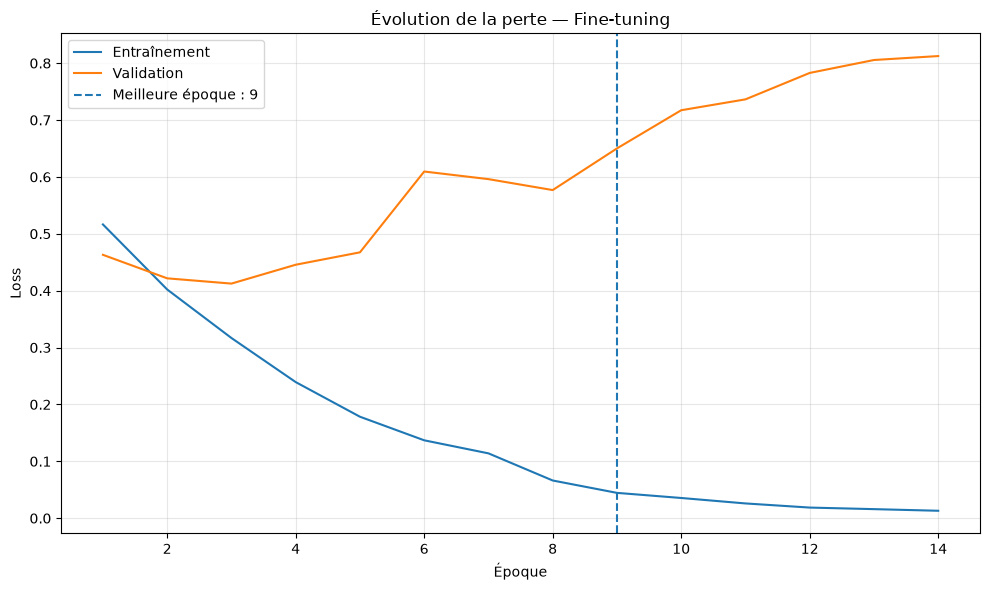

In [63]:
# Courbes de la phase 2

plt.figure(figsize=(10, 6))

plt.plot(
    history_phase2_df.index,
    history_phase2_df["loss"],
    label="Entraînement"
)

plt.plot(
    history_phase2_df.index,
    history_phase2_df["val_loss"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase2,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase2}"
)

plt.title("Évolution de la perte — Fine-tuning")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Dès les premières époques de fine-tuning, la loss d'entraînement continue de diminuer tandis que la loss de validation augmente progressivement. Cet écart traduit un surapprentissage, justifiant l'arrêt à la 9ᵉ époque, où les performances de validation sont optimales

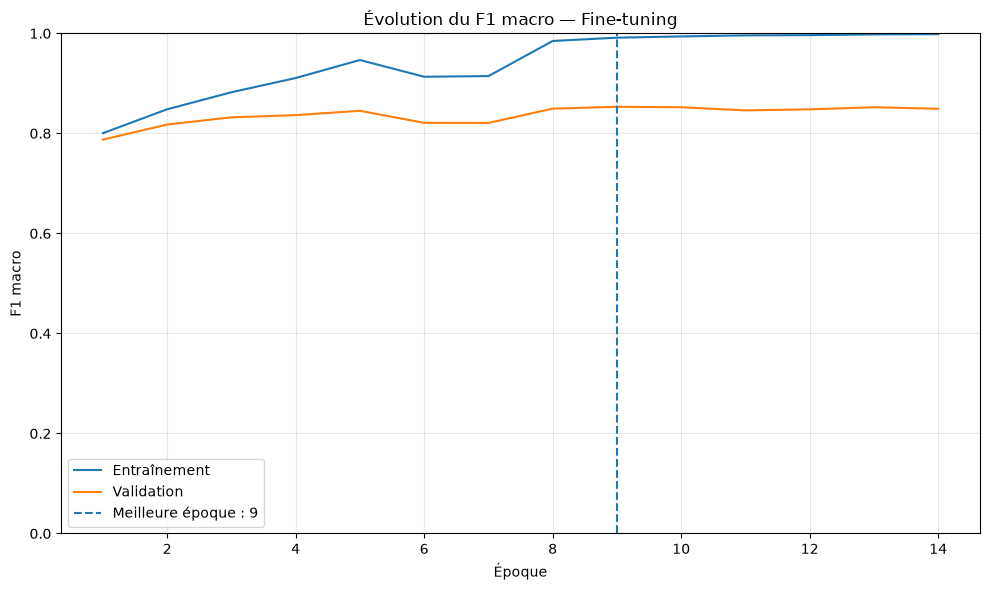

In [64]:
# Courbes de la phase 2

plt.figure(figsize=(10, 6))

plt.plot(
    history_phase2_df.index,
    history_phase2_df["f1_macro"],
    label="Entraînement"
)

plt.plot(
    history_phase2_df.index,
    history_phase2_df["val_f1_macro"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase2,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase2}"
)

plt.title("Évolution du F1 macro — Fine-tuning")
plt.xlabel("Époque")
plt.ylabel("F1 macro")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Le F1 macro augmente jusqu'à la 9ᵉ époque, puis se stabilise sur le jeu de validation tandis qu'il continue d'augmenter en entraînement. Cette divergence confirme le surapprentissage, ce qui justifie l'arrêt du fine-tuning à cette époque.

### Évaluation finale du modèle fine-tuné

Le meilleur modèle obtenu pendant le fine-tuning est chargé depuis le fichier
de sauvegarde.

L’évaluation est ensuite réalisée sur le jeu de test indépendant, qui n’a pas
été utilisé pour entraîner le modèle ni pour sélectionner la meilleure époque.

In [65]:
# Chargement du meilleur modèle après fine-tuning

best_model_phase2 = keras.models.load_model(
    PHASE2_MODEL_PATH
)

print("Meilleur modèle fine-tuné chargé.")
print("Chemin :", PHASE2_MODEL_PATH)

Meilleur modèle fine-tuné chargé.
Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/outputs_resnet50_3classes/resnet50_finetuning_best.keras


In [66]:
# Vérification rapide avec evaluate
# Cette première évaluation fournit la perte et l’accuracy, mais nous allons ensuite calculer toutes les métriques détaillées.

test_loss_phase2, test_accuracy_phase2 = (
    best_model_phase2.evaluate(
        test_ds,
        verbose=1
    )
)

print("\nÉvaluation Keras sur le test :")
print(f"Test loss     : {test_loss_phase2:.4f}")
print(f"Test accuracy : {test_accuracy_phase2:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8853 - loss: 0.5390

Évaluation Keras sur le test :
Test loss     : 0.5390
Test accuracy : 0.8853


In [67]:
# Génération des prédictions

y_true_phase2 = []
y_pred_phase2 = []
y_prob_phase2 = []

for images, labels in test_ds:

    probabilities = best_model_phase2.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true_phase2.extend(labels.numpy())
    y_pred_phase2.extend(predictions)
    y_prob_phase2.extend(probabilities)

y_true_phase2 = np.array(y_true_phase2)
y_pred_phase2 = np.array(y_pred_phase2)
y_prob_phase2 = np.array(y_prob_phase2)

print("Nombre d'images évaluées :", len(y_true_phase2))
print("Forme des probabilités :", y_prob_phase2.shape)

Nombre d'images évaluées : 2084
Forme des probabilités : (2084, 3)


In [68]:
# Calcul des métriques finales

accuracy_phase2 = accuracy_score(
    y_true_phase2,
    y_pred_phase2
)

balanced_accuracy_phase2 = balanced_accuracy_score(
    y_true_phase2,
    y_pred_phase2
)

precision_phase2 = precision_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

recall_phase2 = recall_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

f1_phase2 = f1_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

results_phase2 = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "Valeur": [
        accuracy_phase2,
        balanced_accuracy_phase2,
        precision_phase2,
        recall_phase2,
        f1_phase2
    ]
})

results_phase2

,Métrique,Valeur
0,Accuracy,0.885317
1,Balanced Accuracy,0.860971
2,Precision macro,0.865493
3,Recall macro,0.860971
4,F1 macro,0.863124


In [69]:
# Rapport de classification
print("Rapport phase_2")
print(
    classification_report(
        y_true_phase2,
        y_pred_phase2,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Rapport phase_2
              precision    recall  f1-score   support

       COVID     0.7922    0.7804    0.7862       337
      Normal     0.9066    0.9280    0.9172      1014
   Pneumonia     0.8978    0.8745    0.8860       733

    accuracy                         0.8853      2084
   macro avg     0.8655    0.8610    0.8631      2084
weighted avg     0.8850    0.8853    0.8850      2084



Après le fine-tuning, le modèle atteint un F1 macro de 0,863. Les performances progressent pour les trois classes, avec une amélioration particulièrement marquée pour COVID (F1 = 0,786), confirmant l'apport du fine-tuning.

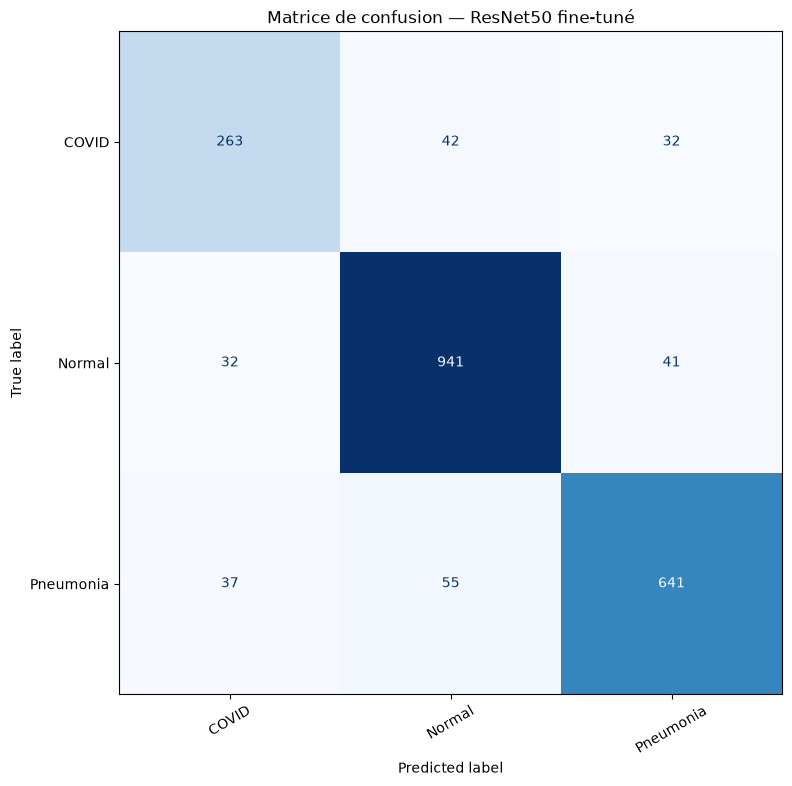

In [70]:
# Matrice de confusion

cm_phase2 = confusion_matrix(
    y_true_phase2,
    y_pred_phase2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_phase2,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Matrice de confusion — ResNet50 fine-tuné")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

La matrice de confusion montre une nette amélioration après le fine-tuning. Les trois classes sont mieux reconnues, avec une diminution des confusions, notamment entre COVID et Pneumonia, confirmant le gain de performance du modèle.

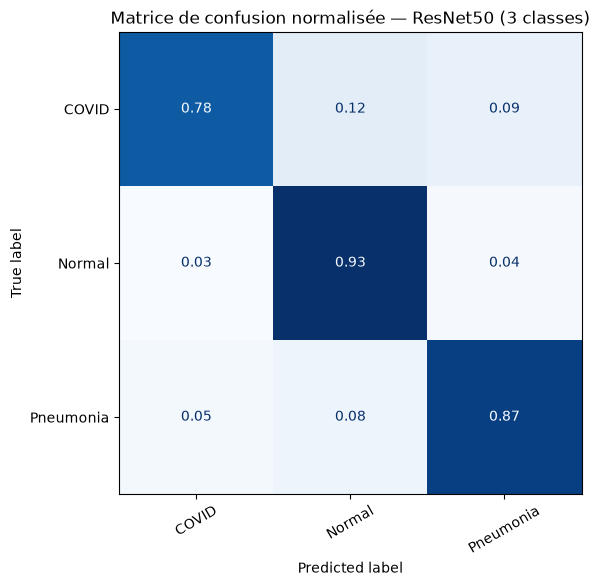

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Dossier des prédictions
PRED_DIR = OUTPUT_DIR / "predictions"

# Chargement
y_true = np.load(PRED_DIR / "y_true_test_resnet50_3classes.npy")
y_pred = np.load(PRED_DIR / "y_pred_test_resnet50_3classes.npy")
class_names = np.load(PRED_DIR / "class_names_resnet50_3classes.npy")

# Matrice de confusion normalisée
cm_norm = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

# Affichage
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format=".2f",
    ax=ax,
    colorbar=False
)

plt.title("Matrice de confusion normalisée — ResNet50 (3 classes)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Sauvegardes

In [71]:
# Dossier de sauvegarde des prédictions
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

np.save(
    PREDICTIONS_DIR / "y_true_test_resnet50_3classes.npy",
    y_true_phase2
)

np.save(
    PREDICTIONS_DIR / "y_prob_test_resnet50_3classes.npy",
    y_prob_phase2
)

print(
    "Sauvegardés : "
    "y_true_test_resnet50_3classes.npy, "
    "y_prob_test_resnet50_3classes.npy"
)

Sauvegardés : y_true_test_resnet50_3classes.npy, y_prob_test_resnet50_3classes.npy


In [73]:
# Création du dossier
PRED_DIR = OUTPUT_DIR / "predictions"
PRED_DIR.mkdir(parents=True, exist_ok=True)

# Labels réels
np.save(
    PRED_DIR / "y_true_test_resnet50_3classes.npy",
    y_true_phase2
)

# Probabilités prédites
np.save(
    PRED_DIR / "y_prob_test_resnet50_3classes.npy",
    y_prob_phase2
)

# Classe prédite
y_pred_phase2 = np.argmax(y_prob_phase2, axis=1)

np.save(
    PRED_DIR / "y_pred_test_resnet50_3classes.npy",
    y_pred_phase2
)

# Noms des classes
np.save(
    PRED_DIR / "class_names_resnet50_3classes.npy",
    np.array(class_names)
)

print("Prédictions sauvegardées avec succès.")

Prédictions sauvegardées avec succès.


In [72]:
pd.DataFrame(history_phase2.history).to_csv(
    OUTPUT_DIR / "history_resnet50_3classes.csv",
    index=False
)

## Interprétabilité du modèle avec Grad-CAM

Grad-CAM permet de visualiser les régions de l’image ayant le plus contribué
à la prédiction du modèle.

La carte d’activation est calculée à partir de la dernière sortie
convolutionnelle de ResNet50, puis superposée à la radiographie originale.

In [74]:
# Vérifier la couche utilisée

resnet_base = best_model_phase2.get_layer("resnet50")

print("Nom du modèle de base :", resnet_base.name)
print("Forme de sa sortie    :", resnet_base.output_shape)
print("Dernière couche       :", resnet_base.layers[-1].name)

Nom du modèle de base : resnet50
Forme de sa sortie    : (None, 7, 7, 2048)
Dernière couche       : conv5_block3_out


In [75]:
# Fonction de restauration de l’image

def deprocess_resnet50(image):
    """
    Restaure une image prétraitée avec
    tf.keras.applications.resnet50.preprocess_input
    afin de pouvoir l'afficher en RGB.
    """
    image = image.numpy().copy()

    # Réintégration des moyennes ImageNet en ordre BGR
    image[..., 0] += 103.939
    image[..., 1] += 116.779
    image[..., 2] += 123.680

    # Conversion BGR vers RGB
    image = image[..., ::-1]

    return np.clip(image, 0, 255).astype("uint8")

In [76]:
# Construction des deux sous-modèles nécessaires pour Grad-CAM

# Modèle ResNet50 imbriqué dans le modèle complet
resnet_base = best_model_phase2.get_layer("resnet50")

# Dernière couche convolutionnelle de ResNet50
LAST_CONV_LAYER_NAME = "conv5_block3_out"

last_conv_layer = resnet_base.get_layer(
    LAST_CONV_LAYER_NAME
)

# Sous-modèle :
# image -> dernière carte convolutionnelle + sortie finale de ResNet50
conv_model = keras.Model(
    inputs=resnet_base.inputs,
    outputs=[
        last_conv_layer.output,
        resnet_base.output
    ],
    name="resnet50_gradcam"
)

print("Couche Grad-CAM :", last_conv_layer.name)
print("Sortie convolutionnelle :", last_conv_layer.output.shape)
print("Sortie ResNet50 :", resnet_base.output.shape)

Couche Grad-CAM : conv5_block3_out
Sortie convolutionnelle : (None, 7, 7, 2048)
Sortie ResNet50 : (None, 7, 7, 2048)


In [77]:
# Construction des deux sous-modèles nécessaires pour Grad-CAM

# Entrée correspondant à la sortie de ResNet50
classifier_input = keras.Input(
    shape=resnet_base.output_shape[1:],
    name="classifier_input"
)

x = classifier_input

# Application des couches situées après ResNet50
resnet_layer_index = best_model_phase2.layers.index(
    resnet_base
)

for layer in best_model_phase2.layers[
    resnet_layer_index + 1:
]:
    x = layer(x)

classifier_model = keras.Model(
    inputs=classifier_input,
    outputs=x,
    name="classification_head"
)

classifier_model.summary()

Model: "classification_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ classifier_input (InputLayer)   │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,147 (24.01 KB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# fonction Grad-CAM

def make_gradcam_heatmap(
    image_batch,
    conv_model,
    classifier_model,
    class_index=None
):
    """
    Calcule une carte Grad-CAM pour le modèle ResNet50 imbriqué.
    """

    with tf.GradientTape() as tape:

        # Cartes convolutives et sortie finale du ResNet50
        conv_outputs, resnet_features = conv_model(
            image_batch,
            training=False
        )

        # Nécessaire pour calculer le gradient par rapport aux activations
        tape.watch(conv_outputs)

        # Passage dans la tête de classification
        predictions = classifier_model(
            resnet_features,
            training=False
        )

        if class_index is None:
            class_index = tf.argmax(
                predictions[0]
            )

        class_score = predictions[
            :,
            class_index
        ]

    gradients = tape.gradient(
        class_score,
        conv_outputs
    )

    if gradients is None:
        raise RuntimeError(
            "Les gradients n'ont pas pu être calculés."
        )

    # Importance moyenne de chaque canal
    channel_weights = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    feature_maps = conv_outputs[0]

    # Somme pondérée des cartes d'activation
    heatmap = tf.reduce_sum(
        feature_maps * channel_weights,
        axis=-1
    )

    # Grad-CAM conserve les contributions positives
    heatmap = tf.nn.relu(heatmap)

    # Normalisation entre 0 et 1
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return (
        heatmap.numpy(),
        predictions[0].numpy(),
        int(class_index.numpy())
    )

In [79]:
# Fonction de superposition

def overlay_gradcam(
    original_image,
    heatmap,
    alpha=0.4
):
    """
    Superpose une carte Grad-CAM à l'image originale.
    """

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        size=original_image.shape[:2]
    ).numpy().squeeze()

    # Transformation de la heatmap en image colorée
    colored_heatmap = plt.get_cmap("jet")(
        heatmap_resized
    )[..., :3]

    colored_heatmap = (
        colored_heatmap * 255
    ).astype("uint8")

    superimposed_image = (
        (1 - alpha) * original_image
        + alpha * colored_heatmap
    )

    return np.clip(
        superimposed_image,
        0,
        255
    ).astype("uint8")

In [80]:
def display_gradcam_grid(
    dataset,
    model,
    conv_model,
    classifier_model,
    class_names,
    n_images=12,
    only_errors=False
):
    """
    Affiche plusieurs images avec leur Grad-CAM.

    Parameters
    ----------
    dataset : tf.data.Dataset
        Dataset prétraité pour ResNet50.
    model : keras.Model
        Modèle complet fine-tuné.
    conv_model : keras.Model
        Sous-modèle fournissant les activations convolutionnelles.
    classifier_model : keras.Model
        Tête de classification.
    class_names : list[str]
        Noms des classes.
    n_images : int
        Nombre maximal d'images à afficher.
    only_errors : bool
        Si True, affiche uniquement les prédictions incorrectes.
    """

    selected = []

    for images_batch, labels_batch in dataset:

        probabilities_batch = model.predict(
            images_batch,
            verbose=0
        )

        predictions_batch = np.argmax(
            probabilities_batch,
            axis=1
        )

        for image_tensor, true_label, pred_label, probabilities in zip(
            images_batch,
            labels_batch.numpy(),
            predictions_batch,
            probabilities_batch
        ):
            is_error = int(true_label) != int(pred_label)

            if only_errors and not is_error:
                continue

            selected.append({
                "image_tensor": image_tensor,
                "true_label": int(true_label),
                "pred_label": int(pred_label),
                "probabilities": probabilities
            })

            if len(selected) >= n_images:
                break

        if len(selected) >= n_images:
            break

    if not selected:
        print("Aucune image correspondant au critère.")
        return

    fig, axes = plt.subplots(
        len(selected),
        2,
        figsize=(10, 4 * len(selected))
    )

    if len(selected) == 1:
        axes = np.array([axes])

    for row, item in enumerate(selected):

        image_tensor = item["image_tensor"]
        true_label = item["true_label"]
        pred_label = item["pred_label"]
        probabilities = item["probabilities"]

        image_batch = tf.expand_dims(
            image_tensor,
            axis=0
        )

        heatmap, _, predicted_class_index = (
            make_gradcam_heatmap(
                image_batch=image_batch,
                conv_model=conv_model,
                classifier_model=classifier_model
            )
        )

        original_image = deprocess_resnet50(
            image_tensor
        )

        gradcam_image = overlay_gradcam(
            original_image,
            heatmap,
            alpha=0.4
        )

        confidence = float(
            probabilities[predicted_class_index]
        )

        true_name = class_names[true_label]
        pred_name = class_names[pred_label]

        status = (
            "Correct"
            if true_label == pred_label
            else "Erreur"
        )

        axes[row, 0].imshow(original_image)
        axes[row, 0].set_title(
            f"Image originale\n"
            f"Classe réelle : {true_name}"
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gradcam_image)
        axes[row, 1].set_title(
            f"{status}\n"
            f"Prédiction : {pred_name}\n"
            f"Confiance : {confidence:.1%}"
        )
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()

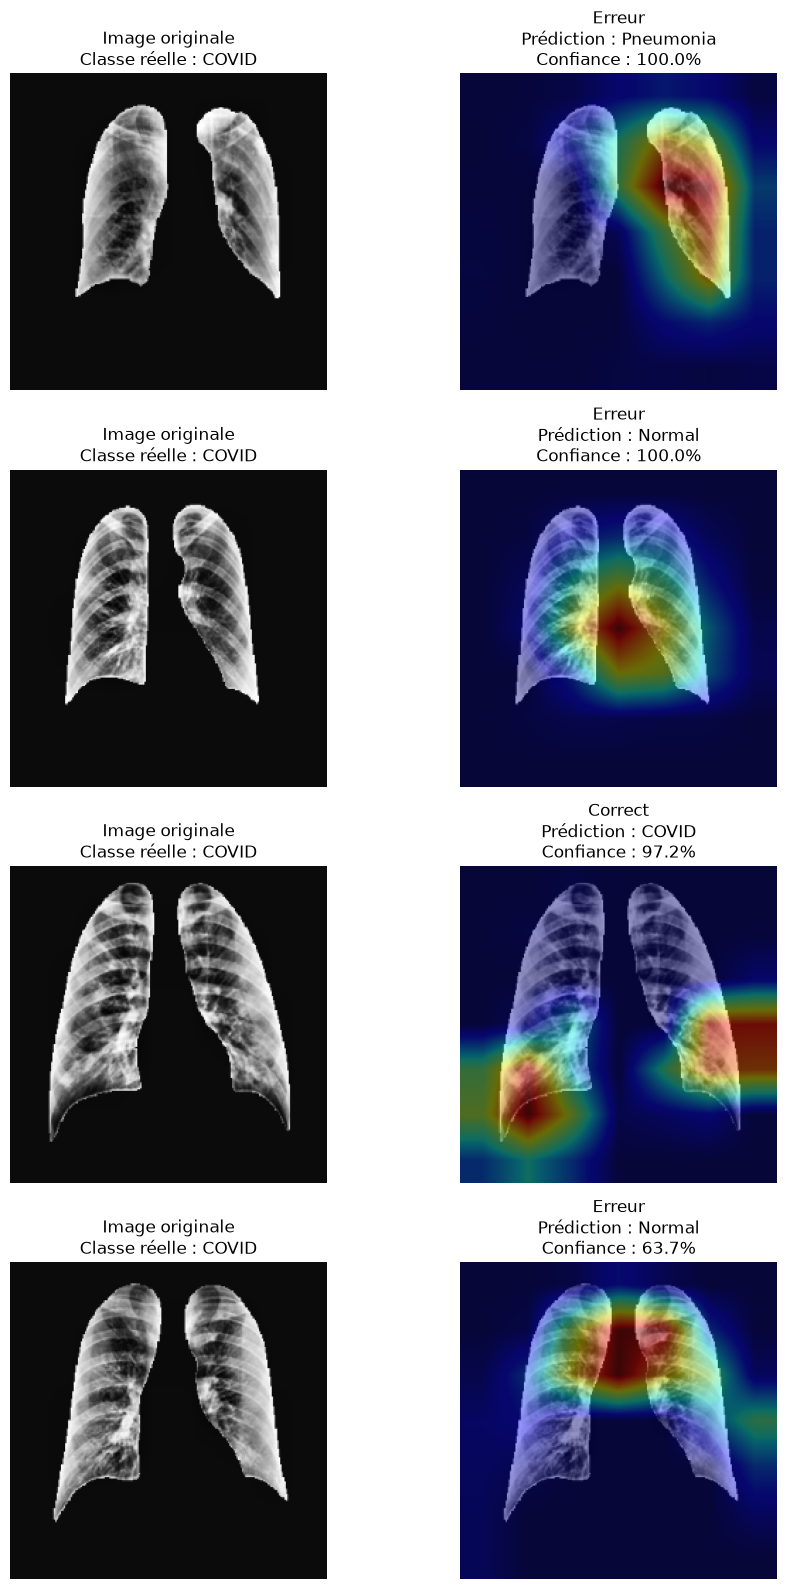

In [81]:
display_gradcam_grid(
    dataset=test_ds,
    model=best_model_phase2,
    conv_model=conv_model,
    classifier_model=classifier_model,
    class_names=class_names,
    n_images=4,
    only_errors=False
)

Les erreurs concernent principalement la classe COVID, souvent confondue avec Normal ou Pneumonia lorsque les lésions sont peu marquées. Les cartes Grad-CAM montrent que le modèle se concentre sur les régions pulmonaires pertinentes, mais certaines activations restent diffuses, expliquant ces confusions.

# Conclusion

## Synthèse

Cette section rassemble l'ensemble des résultats obtenus avec le modèle
fine-tuné.

Les performances sont évaluées à l'aide de plusieurs métriques adaptées
à un problème de classification multiclasse déséquilibré :

- Accuracy
- Balanced Accuracy
- Precision macro
- Recall macro
- F1-score macro

Les résultats sont ensuite comparés à ceux obtenus avant le fine-tuning.

In [82]:
# Tableau comparatif Phase 1 / Phase 2

comparison_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],

    "Phase 1": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1
    ],

    "Fine-tuning": [
        accuracy_phase2,
        balanced_accuracy_phase2,
        precision_phase2,
        recall_phase2,
        f1_phase2
    ]
})

comparison_results["Gain"] = (
    comparison_results["Fine-tuning"]
    - comparison_results["Phase 1"]
)

comparison_results

,Métrique,Phase 1,Fine-tuning,Gain
0,Accuracy,0.808541,0.885317,0.076775
1,Balanced Accuracy,0.786531,0.860971,0.074440
2,Precision macro,0.769924,0.865493,0.095569
3,Recall macro,0.786531,0.860971,0.074440
4,F1 macro,0.774834,0.863124,0.088291


In [83]:
# Tableau formaté en %

comparison_display = comparison_results.copy()

for col in ["Phase 1", "Fine-tuning", "Gain"]:
    comparison_display[col] = (
        comparison_display[col] * 100
    ).map(lambda x: f"{x:.2f} %")

comparison_display

,Métrique,Phase 1,Fine-tuning,Gain
0,Accuracy,80.85 %,88.53 %,7.68 %
1,Balanced Accuracy,78.65 %,86.10 %,7.44 %
2,Precision macro,76.99 %,86.55 %,9.56 %
3,Recall macro,78.65 %,86.10 %,7.44 %
4,F1 macro,77.48 %,86.31 %,8.83 %


## Bénéfice du Fine Tuning

Cette dernière section résume automatiquement les performances obtenues et
l'apport du fine-tuning.

Les conclusions sont calculées directement à partir des résultats du modèle.

In [84]:
gain_accuracy = (
    accuracy_phase2 - accuracy
) * 100

gain_f1 = (
    f1_phase2 - f1
) * 100

gain_balanced = (
    balanced_accuracy_phase2
    - balanced_accuracy
) * 100

print("=" * 70)
print("CONCLUSION DU PROJET")
print("=" * 70)

print()

print(
    f"Accuracy            : {accuracy_phase2:.4f}"
)

print(
    f"Balanced Accuracy   : {balanced_accuracy_phase2:.4f}"
)

print(
    f"F1-score macro      : {f1_phase2:.4f}"
)

print()

print("Apport du fine-tuning")

print(
    f"Accuracy       : +{gain_accuracy:.2f} points"
)

print(
    f"Balanced Acc.  : +{gain_balanced:.2f} points"
)

print(
    f"F1 macro       : +{gain_f1:.2f} points"
)

CONCLUSION DU PROJET

Accuracy            : 0.8853
Balanced Accuracy   : 0.8610
F1-score macro      : 0.8631

Apport du fine-tuning
Accuracy       : +7.68 points
Balanced Acc.  : +7.44 points
F1 macro       : +8.83 points


## Graphiques combinés

In [85]:
# Combinaison des historiques de la phase 1 et du fine-tuning

loss_train_combined = (
    list(history_phase1.history["loss"])
    + list(history_phase2.history["loss"])
)

loss_val_combined = (
    list(history_phase1.history["val_loss"])
    + list(history_phase2.history["val_loss"])
)

f1_train_combined = (
    list(history_phase1.history["f1_macro"])
    + list(history_phase2.history["f1_macro"])
)

f1_val_combined = (
    list(history_phase1.history["val_f1_macro"])
    + list(history_phase2.history["val_f1_macro"])
)

n_epochs_phase1 = len(
    history_phase1.history["loss"]
)

n_epochs_phase2 = len(
    history_phase2.history["loss"]
)

epochs_combined = np.arange(
    1,
    n_epochs_phase1 + n_epochs_phase2 + 1
)

# Meilleure époque du fine-tuning selon le F1 macro de validation
best_epoch_phase2 = (
    np.argmax(
        history_phase2.history["val_f1_macro"]
    )
    + 1
)

best_epoch_phase2_global = (
    n_epochs_phase1
    + best_epoch_phase2
)

print("Époques phase 1 :", n_epochs_phase1)
print("Époques phase 2 :", n_epochs_phase2)
print(
    "Meilleure époque globale :",
    best_epoch_phase2_global
)

Époques phase 1 : 20
Époques phase 2 : 14
Meilleure époque globale : 29


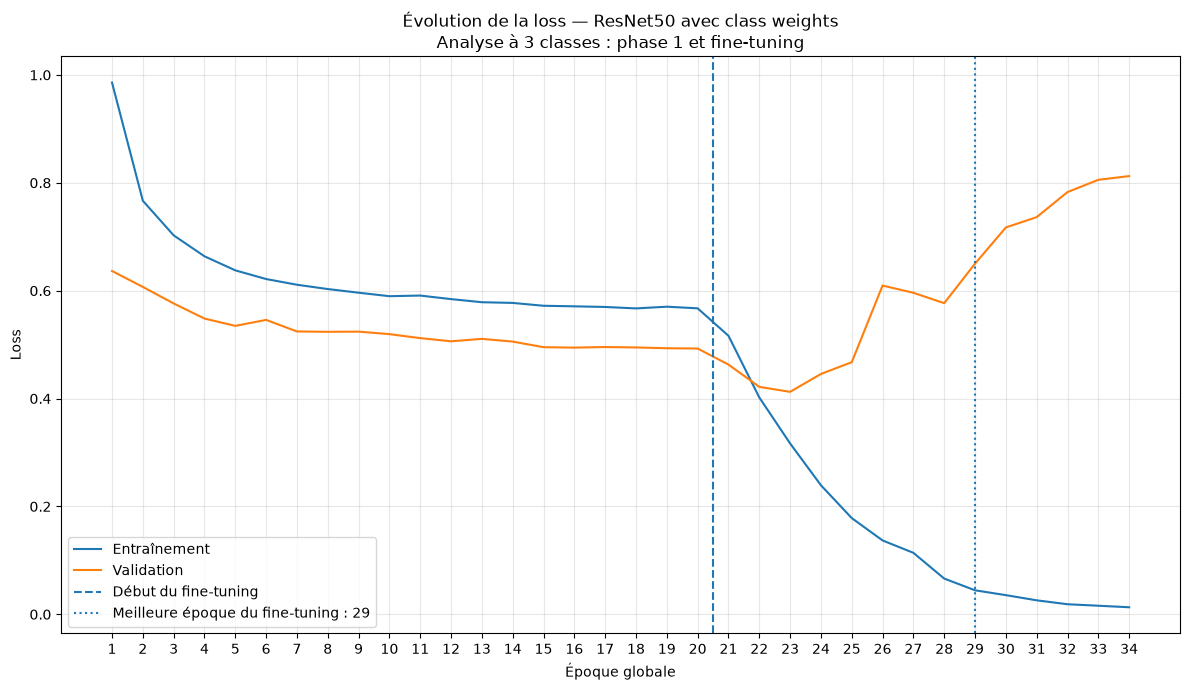

In [86]:
# Évolution combinée de la loss

plt.figure(figsize=(12, 7))

plt.plot(
    epochs_combined,
    loss_train_combined,
    label="Entraînement"
)

plt.plot(
    epochs_combined,
    loss_val_combined,
    label="Validation"
)

# Séparation entre les deux phases
plt.axvline(
    n_epochs_phase1 + 0.5,
    linestyle="--",
    label="Début du fine-tuning"
)

# Meilleure époque du fine-tuning
plt.axvline(
    best_epoch_phase2_global,
    linestyle=":",
    label=(
        "Meilleure époque du fine-tuning : "
        f"{best_epoch_phase2_global}"
    )
)

plt.title(
    "Évolution de la loss — ResNet50 avec class weights\n"
    "Analyse à 3 classes : phase 1 et fine-tuning"
)

plt.xlabel("Époque globale")
plt.ylabel("Loss")

plt.xticks(epochs_combined)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

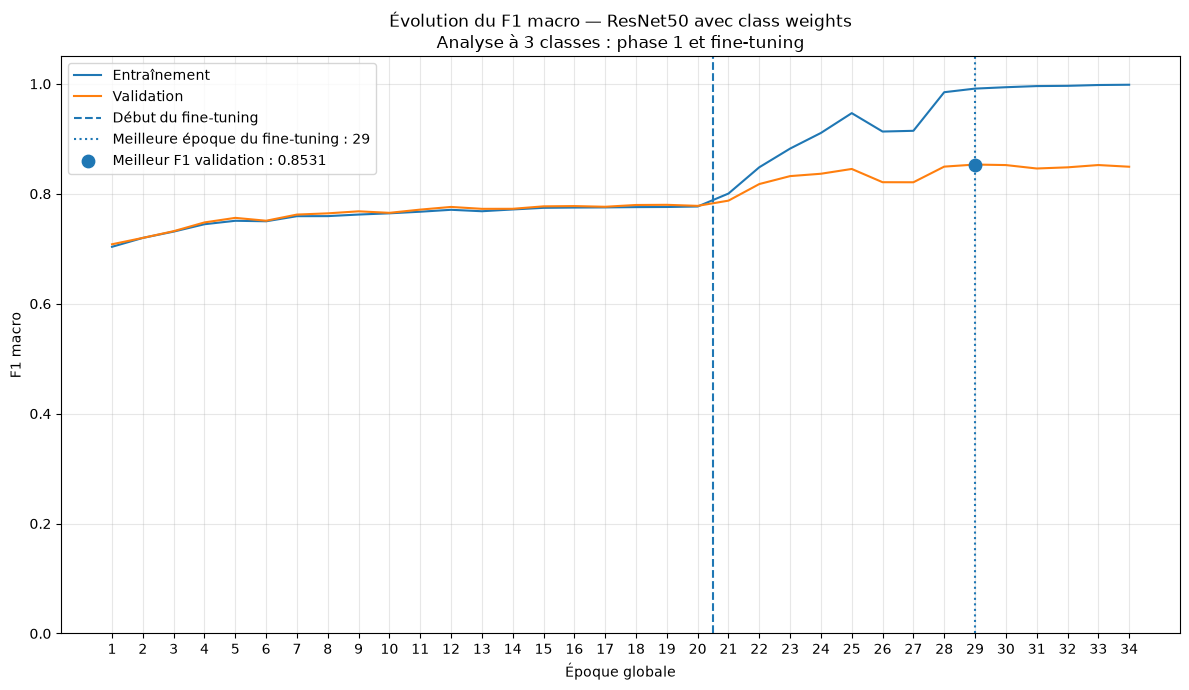

In [87]:
# Évolution combinée du F1 macro

plt.figure(figsize=(12, 7))

plt.plot(
    epochs_combined,
    f1_train_combined,
    label="Entraînement"
)

plt.plot(
    epochs_combined,
    f1_val_combined,
    label="Validation"
)

# Séparation entre les deux phases
plt.axvline(
    n_epochs_phase1 + 0.5,
    linestyle="--",
    label="Début du fine-tuning"
)

# Meilleure époque du fine-tuning
plt.axvline(
    best_epoch_phase2_global,
    linestyle=":",
    label=(
        "Meilleure époque du fine-tuning : "
        f"{best_epoch_phase2_global}"
    )
)

plt.scatter(
    best_epoch_phase2_global,
    f1_val_combined[
        best_epoch_phase2_global - 1
    ],
    s=80,
    zorder=5,
    label=(
        "Meilleur F1 validation : "
        f"{f1_val_combined[best_epoch_phase2_global - 1]:.4f}"
    )
)

plt.title(
    "Évolution du F1 macro — ResNet50 avec class weights\n"
    "Analyse à 3 classes : phase 1 et fine-tuning"
)

plt.xlabel("Époque globale")
plt.ylabel("F1 macro")

plt.xticks(epochs_combined)
plt.ylim(0, 1.05)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Courbes Precision / Recall

In [89]:
# Import des probabilités sur la validation

y_true_val_phase2 = []
y_prob_val_phase2 = []

for images, labels in val_ds:

    probabilities = best_model_phase2.predict(
        images,
        verbose=0
    )

    y_true_val_phase2.extend(
        labels.numpy()
    )

    y_prob_val_phase2.extend(
        probabilities
    )

y_true_val_phase2 = np.array(
    y_true_val_phase2
)

y_prob_val_phase2 = np.array(
    y_prob_val_phase2
)

In [90]:
# Vérification de l'import

assert (
    len(y_true_val_phase2)
    == len(y_prob_val_phase2)
)

assert (
    y_prob_val_phase2.shape[1]
    == len(class_names)
)

print("Correspondance labels-prédictions validée.")

Correspondance labels-prédictions validée.


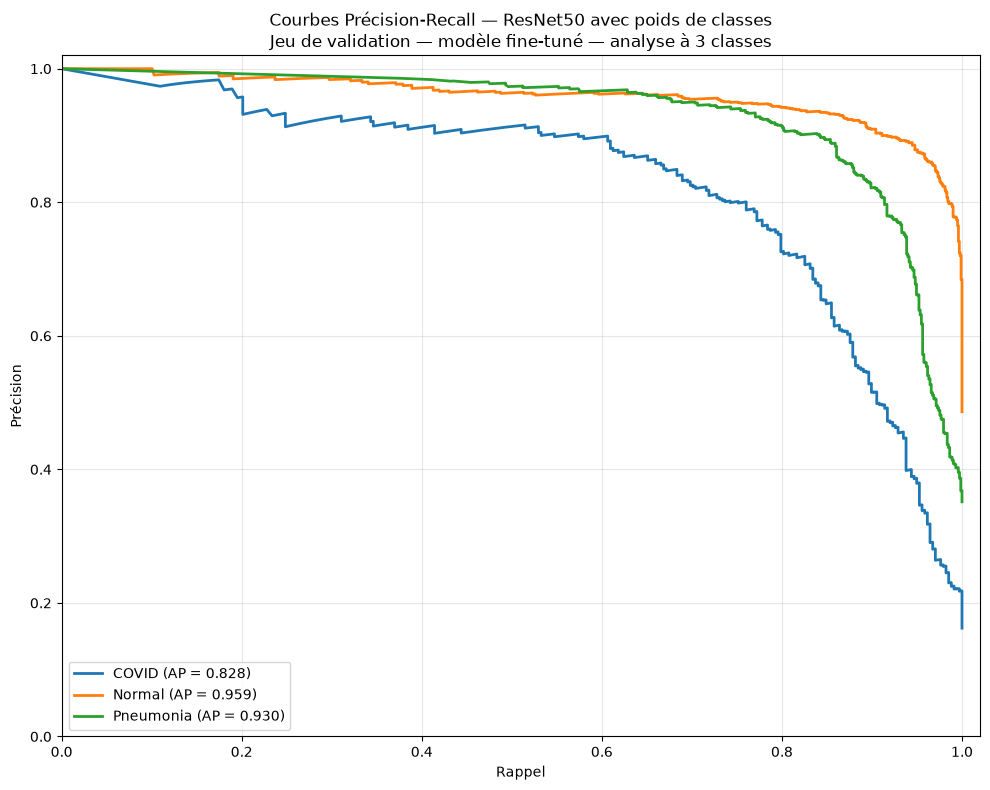

In [91]:
# Courbes Précision-Recall pour les 3 classes

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

plt.figure(figsize=(10, 8))

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        y_true_val_phase2 == class_index
    ).astype(int)

    y_score = y_prob_val_phase2[
        :,
        class_index
    ]

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true_binary,
            y_score
        )
    )

    average_precision = (
        average_precision_score(
            y_true_binary,
            y_score
        )
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP = {average_precision:.3f})"
        )
    )

plt.title(
    "Courbes Précision-Recall — ResNet50 avec poids de classes\n"
    "Jeu de validation — modèle fine-tuné — analyse à 3 classes"
)

plt.xlabel("Rappel")
plt.ylabel("Précision")

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Les courbes Precision-Recall montrent de bonnes performances pour Normal (AP = 0,959) et Pneumonia (AP = 0,930). La classe COVID (AP = 0,828) reste la plus difficile à discriminer, malgré l'utilisation des poids de classes.

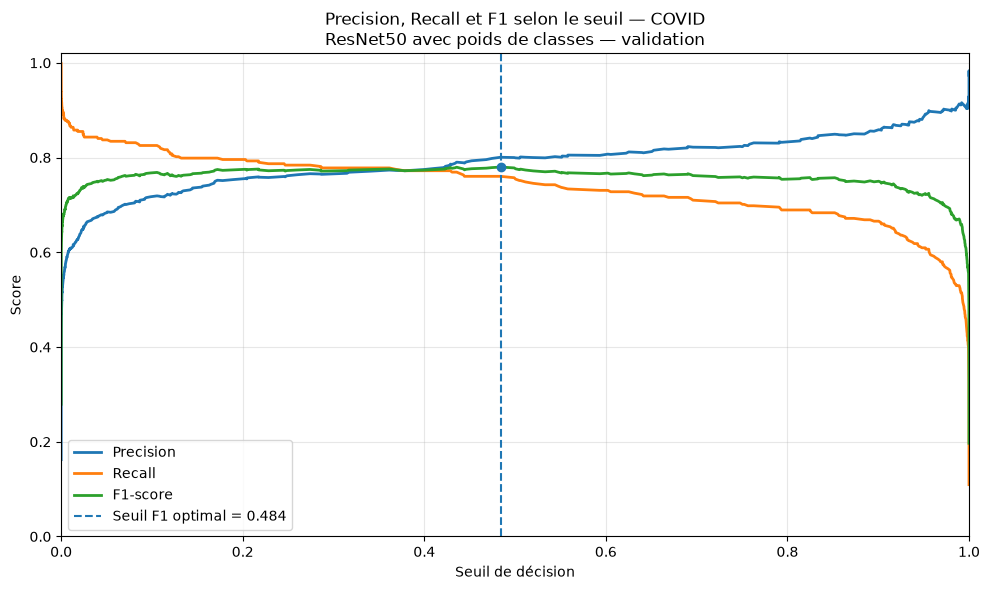

Classe : COVID
Seuil optimal : 0.4840
Precision : 0.8006
Recall : 0.7604
F1-score : 0.7800
--------------------------------------------------


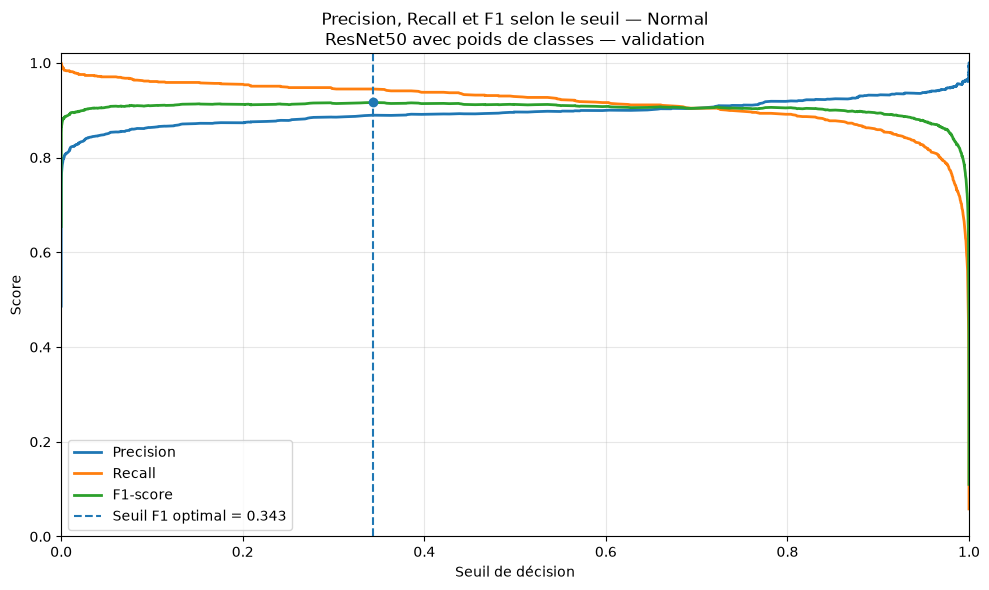

Classe : Normal
Seuil optimal : 0.3432
Precision : 0.8894
Recall : 0.9447
F1-score : 0.9162
--------------------------------------------------


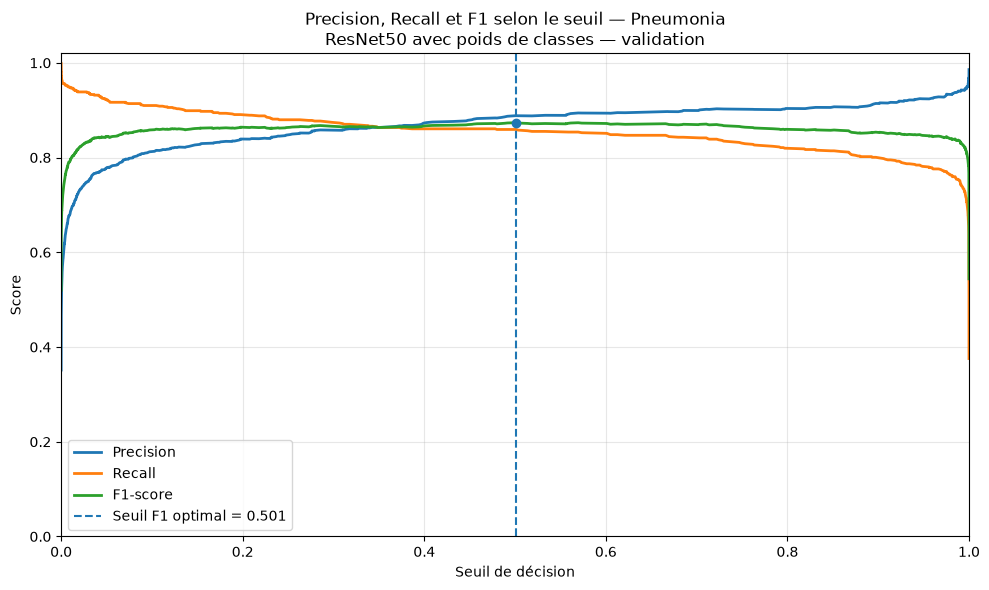

Classe : Pneumonia
Seuil optimal : 0.5010
Precision : 0.8884
Recall : 0.8593
F1-score : 0.8736
--------------------------------------------------


In [92]:
# Courbe Précision / Recall selon le seuil pour les 3 classes

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        y_true_val_phase2 == class_index
    ).astype(int)

    y_score = y_prob_val_phase2[
        :,
        class_index
    ]

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true_binary,
            y_score
        )
    )

    # precision et recall ont une valeur de plus
    # que le tableau thresholds
    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(
        f1_by_threshold
    )

    best_threshold = thresholds[
        best_index
    ]

    best_precision = precision_by_threshold[
        best_index
    ]

    best_recall = recall_by_threshold[
        best_index
    ]

    best_f1 = f1_by_threshold[
        best_index
    ]

    plt.figure(figsize=(10, 6))

    plt.plot(
        thresholds,
        precision_by_threshold,
        label="Precision",
        linewidth=2
    )

    plt.plot(
        thresholds,
        recall_by_threshold,
        label="Recall",
        linewidth=2
    )

    plt.plot(
        thresholds,
        f1_by_threshold,
        label="F1-score",
        linewidth=2
    )

    plt.axvline(
        best_threshold,
        linestyle="--",
        label=(
            f"Seuil F1 optimal = "
            f"{best_threshold:.3f}"
        )
    )

    plt.scatter(
        best_threshold,
        best_f1,
        zorder=5
    )

    plt.title(
        f"Precision, Recall et F1 selon le seuil — {class_name}\n"
        "ResNet50 avec poids de classes — validation"
    )

    plt.xlabel("Seuil de décision")
    plt.ylabel("Score")

    plt.xlim(0, 1)
    plt.ylim(0, 1.02)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Classe : {class_name}")
    print(
        f"Seuil optimal : "
        f"{best_threshold:.4f}"
    )
    print(
        f"Precision : "
        f"{best_precision:.4f}"
    )
    print(
        f"Recall : "
        f"{best_recall:.4f}"
    )
    print(
        f"F1-score : "
        f"{best_f1:.4f}"
    )
    print("-" * 50)

Le seuil optimal pour la classe COVID est de 0,484, offrant le meilleur compromis entre précision (0,78) et rappel (0,76) avec un F1-score de 0,77. Un seuil inférieur à 0,5 améliore légèrement la détection des cas COVID.

In [93]:
# Tableau récapitulatif des seuils optimaux


threshold_results = []

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        y_true_val_phase2 == class_index
    ).astype(int)

    y_score = y_prob_val_phase2[
        :,
        class_index
    ]

    precision, recall, thresholds = (
        precision_recall_curve(
            y_true_binary,
            y_score
        )
    )

    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(
        f1_by_threshold
    )

    threshold_results.append({
        "classe": class_name,
        "index_classe": class_index,
        "seuil_optimal_f1": thresholds[
            best_index
        ],
        "precision_validation": (
            precision_by_threshold[
                best_index
            ]
        ),
        "recall_validation": (
            recall_by_threshold[
                best_index
            ]
        ),
        "f1_validation": (
            f1_by_threshold[
                best_index
            ]
        ),
        "average_precision": (
            average_precision_score(
                y_true_binary,
                y_score
            )
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df = (
    threshold_results_df.round(4)
)

threshold_results_df

,classe,index_classe,seuil_optimal_f1,precision_validation,recall_validation,f1_validation,average_precision
0,COVID,0,0.4840,0.8006,0.7604,0.7800,0.8277
1,Normal,1,0.3432,0.8894,0.9447,0.9162,0.9588
2,Pneumonia,2,0.5010,0.8884,0.8593,0.8736,0.9298


Les seuils optimaux diffèrent selon les classes : 0,484 pour COVID, 0,343 pour Normal et 0,501 pour Pneumonia. Un ajustement spécifique par classe permet d'améliorer le compromis précision/rappel, en particulier pour la détection des cas COVID.